In [1]:
import os
import gc
import glob
import json
#import h5py
import numpy as np
import pickle
import pandas as pd
#from IPython.display import Audio, display
from collections import Counter, defaultdict
from pynwb import NWBHDF5IO
from datetime import datetime
import scipy.signal
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

In [2]:
from extract_features import extractHG, stackFeatures, downsampleLabels
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
#from feature_vizualizer import PhonemeFeatureVisualizer
#from markov_phoneme_model import MarkovPhonemeModel
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [3]:
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic 
from dataset_config import Dutch30Config

from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

In [4]:
plt.ion()

In [5]:
dutch30_dir = DUTCH_30_PATH

# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))

In [6]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [7]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')
#visualizer = PhonemeFeatureVisualizer(output_dir='./phoneme_visualizations')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [8]:
# Create config
# config = Dutch30Config()

# # Pass config to both extractor and pipeline
# extractor = Dutch30FeatureExtractor(config=config)

# pipeline = Dutch30Pipeline(
#     dutch30_extractor=extractor,
#     config=config, 
#     debug_mode=True,
#     pca_components=100,
#     feature_extraction_method='high_gamma', 
    
# )

# # Debug a specific patient
# pipeline.debug_sentence_parsing('sub-p21', max_samples=3)
# print([attr for attr in dir(pipeline_debug) if 'detect' in attr.lower()])

In [9]:
# Load pre-trained wav2vec model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
config = Dutch30Config()
extractor = Dutch30FeatureExtractor()

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz


In [10]:
# #check where method is used
# import os

# search_term = "standardize_channels"
# project_path = r"D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch_step2"

# for filename in os.listdir(project_path):
#     if filename.endswith('.py'):
#         filepath = os.path.join(project_path, filename)
#         with open(filepath, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             for line_num, line in enumerate(lines, 1):
#                 if search_term in line and 'def ' not in line and not line.strip().startswith('#'):
#                     print(f"{filename}:{line_num}: {line.strip()}")

In [11]:
# pipeline.step1_load_dutch30_data(num_patients = 10)
# #pipeline.step2_3_use_existing_split()
# pipeline.step2_split_by_instances()

# pid = 'P01'
# word_segments = pipeline.split_result['word_segments_dict'][pid]
# word = list(word_segments['words'].keys())[0]
# instance = word_segments['words'][word]['instances'][0]

# print(f"Audio available: {'audio_segment' in instance}")
# print(f"Audio shape: {instance['audio_segment'].shape if 'audio_segment' in instance else 'N/A'}")

In [12]:
# diag = Dutch30PhonemeDetectionDiagnostic(pipeline)
# diag.visualize_word_analysis('P01', word_name = 'vogelkooitje', save_path='p21_word5.png')

In [13]:
# #diag.visualize_multifeature_analysis('P01', word_index=50)
# diag.visualize_rms_boundaries('P01',  word_name = 'vogelkooitje')

In [14]:
# # Quick check first 10 words
# diag.batch_diagnostic('sub-p21', num_samples=5)

In [15]:
config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)

band_powers_pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    config=config, 
    debug_mode=False,
    pca_components= None, #100,
    feature_extraction_method = 'band_powers',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
    use_rms_boundaries=False,   
    use_multifeature=False,
    use_wav2vec=True,
    subtract_baseline=True,
    #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
)

high_gamma_pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    config=config, 
    debug_mode=False,
    pca_components= None, #100,
    feature_extraction_method = 'high_gamma',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
    use_rms_boundaries=False,   
    use_multifeature=False,
    use_wav2vec=True,
    subtract_baseline=True,
    #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
)

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 1 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: band_powers, PCA=None, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: 

In [16]:
# step_0
# pipeline.analyze_dutch30_channels()
#pipeline.step1_load_dutch30_data(num_patients = 20)
#best_patients = ['P03', 'P11', 'P16', 'P17', 'P21']
#pipeline.step1_load_dutch30_data(patient_ids=best_patients)
band_powers_pipeline.step1_load_dutch30_data(patient_range=(1,30))
high_gamma_pipeline.step1_load_dutch30_data(patient_range=(1,30))
band_powers_pipeline.split_result = None
high_gamma_pipeline.split_result = None
band_powers_pipeline.step2_split_by_instances();
high_gamma_pipeline.step2_split_by_instances();

UnifiedPhonemePipeline: Step 1: Loading Dutch30...
UnifiedPhonemePipeline:   Using patients P01 to P30: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline: Step 1: Loading Dutch30...
UnifiedPhonemePipeline:   Using patients P01 to P30: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline: P01: 70 train, 31 test, baseline: (780,)
UnifiedPhonemePipeline: P02: 68 train, 33 test, baseline: (780,)
UnifiedPhonemePipeline: P03: 71 train, 30 test, baseline: (798,)
UnifiedPhonemePipeline: P04: 78 train, 23 test, baseline: (768,)
UnifiedPhonemePipeline: P06: 76 train, 25 test, baseline: (798,)
UnifiedPhonemePipeline: P07: 66 train, 35 test, baseline: (780,)
UnifiedPhonemePipeline

In [17]:
band_powers_pipeline.step4_custom_detector()
high_gamma_pipeline.step4_custom_detector()

UnifiedPhonemePipeline: Step 4: Initializing detector...
AcousticChangeDetector: Initialized with DEBUG_MODE=False
AcousticChangeDetector: Using feature extraction method: band_powers
AcousticChangeDetector: Initializing wav2vec model for boundary detection...


C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully
UnifiedPhonemePipeline: Step 4: Initializing detector...
AcousticChangeDetector: Initialized with DEBUG_MODE=False
AcousticChangeDetector: Using feature extraction method: high_gamma
AcousticChangeDetector: Initializing wav2vec model for boundary detection...
AcousticChangeDetector: Wav2vec model initialized successfully


In [18]:
# Enable debug mode to see what's happening
# high_gamma_pipeline.DEBUG_MODE = True
# band_powers_pipeline.DEBUG_MODE = True

# Then re-run step 5
band_powers_pipeline.step5_accumulate_data_dutch30();
high_gamma_pipeline.step5_accumulate_data_dutch30();

UnifiedPhonemePipeline: 
Step 5 starting:
UnifiedPhonemePipeline:   Train patients: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline:   Available samples: train=4815, test=2496
AcousticChangeDetector: Processing 4815 instances in 38 batches (no replacement)
AcousticChangeDetector: Processing batch 1/38
          Building batch from 128 instances...
          Batch built: 128 words
          Processing batch (phoneme detection)...
AcousticChangeDetector:   Need 10 peaks but only found 5 for word 'zevenduizend' (Patient P01)
AcousticChangeDetector:   Need 10 peaks but only found 9 for word 'vogelkooitje' (Patient P01)
AcousticChangeDetector:   Need 12 peaks but only found 11 for word 'teruggekregen' (Patient P01)
AcousticChangeDetector:   Need 8 peaks but only found 7 for word 'onmiddellijk' (Patient P01)
AcousticChangeDetecto

In [19]:
band_powers_pipeline.dutch30_step6_resolve_unknowns();
high_gamma_pipeline.dutch30_step6_resolve_unknowns();

UnifiedPhonemePipeline: Train data keys: dict_keys(['features', 'spectrograms', 'phoneme_labels', 'phoneme_words', 'phoneme_participant_ids', 'phoneme_positions', 'metadata'])
UnifiedPhonemePipeline: Unknown count: 5752
PhonemeValidator: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Step 6: Validator initialized
UnifiedPhonemePipeline: Resolving 5752 unknown phonemes in training...
UnifiedPhonemePipeline: Test unknowns: 2668
UnifiedPhonemePipeline: WARNING: Still 114 unknown in train, 51 in test
UnifiedPhonemePipeline: Step 6 complete: 19025 train, 9458 test
UnifiedPhonemePipeline:   Unknown remaining: 114 train, 51 test
UnifiedPhonemePipeline: Train data keys: dict_keys(['features', 'phoneme_labels', 'phoneme_words', 'phoneme_positions', 'phoneme_participant_ids', 'spectrograms', 'metadata'])
UnifiedPhonemePipeline: Unknown count: 5752
PhonemeValidator: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Step 6: Validator initialized
UnifiedPhonemePipeline: Resolving

In [20]:
# band_powers_pipeline.checkpoint_after_step6()
# high_gamma_pipeline.checkpoint_after_step6()
band_powers_pipeline.checkpoint_after_step6(sample_fraction=1)
high_gamma_pipeline.checkpoint_after_step6(sample_fraction=1)

UnifiedPhonemePipeline: Saving checkpoint: pipeline_band_powers_pcaNone_sample100_after_step6_20251217_110036.pkl
UnifiedPhonemePipeline: Checkpoint saved: pipeline_band_powers_pcaNone_sample100_after_step6_20251217_110036.pkl
UnifiedPhonemePipeline: Saving checkpoint: pipeline_high_gamma_pcaNone_sample100_after_step6_20251217_110038.pkl
UnifiedPhonemePipeline: Checkpoint saved: pipeline_high_gamma_pcaNone_sample100_after_step6_20251217_110038.pkl


'C:\\mozg\\code\\SingleWordProductionDutch\\results\\dutch30\\pipeline_high_gamma_pcaNone_sample100_after_step6_20251217_110038.pkl'

In [21]:
# pipeline.try_load_checkpoint(sample_fraction=0.0001)

In [22]:
band_powers_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
high_gamma_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);

UnifiedPhonemePipeline: Filtered training: 18919 samples (from 19025)
UnifiedPhonemePipeline: Filtered training: 18915 samples (from 19025)


In [23]:
# Check if pipeline has any partial results
if hasattr(high_gamma_pipeline, 'detector'):
    print("Detector exists")
    
# Check if there's any train data accumulating
if hasattr(high_gamma_pipeline, 'train') and high_gamma_pipeline.train is not None:
    print(f"Train data so far: {len(high_gamma_pipeline.train.get('phoneme_labels', []))} phonemes")

Detector exists
Train data so far: 19025 phonemes


In [24]:
def visualize_pipeline_features(pipeline, patient_id=None, save_path=None):
    """
    Visualize features already extracted by the pipeline.
    
    Includes:
    - Basic feature distributions
    - Transient/kurtosis features (computed from pipeline features)
    - Feature separability analysis
    - Phoneme heatmaps
    - Learning curves (overall and feature-specific)
    - Dendrograms
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_id: Optional - filter to specific patient, or None for all
        save_path: Directory to save figures
    
    Returns:
        dict: Analysis results
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from scipy.signal import hilbert
    from sklearn.model_selection import learning_curve, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
    from scipy.spatial.distance import pdist
    from collections import defaultdict
    import os
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get data from pipeline
    features_list = train_data['features']
    labels = train_data['phoneme_labels']
    words = train_data['phoneme_words']
    participant_ids = train_data['phoneme_participant_ids']
    
    # Filter by patient if specified
    if patient_id is not None:
        indices = [i for i, pid in enumerate(participant_ids) if pid == patient_id]
        if not indices:
            print(f"No data found for patient {patient_id}")
            return None
        features_list = [features_list[i] for i in indices]
        labels = [labels[i] for i in indices]
        words = [words[i] for i in indices]
        participant_ids = [participant_ids[i] for i in indices]
        print(f"Filtered to {len(indices)} samples for {patient_id}")
    
    print(f"Total samples: {len(features_list)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(participant_ids))}")
    
    # Define vowels
    vowels = getattr(pipeline.config, 'vowels', None)
    if vowels is None:
        vowels = {
            # Short monophthongs
            'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
            
            # Long vowels (IPA length marker)
            'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
            
            # Long vowels (colon notation - in case your data uses this)
            'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
            
            # Diphthongs
            'ɛi', 'œy', 'ɑu', 'ʌu',
        }
    
    # ========================================================================
    # FEATURE EXTRACTION FROM PIPELINE DATA
    # ========================================================================
    
    def extract_summary_features(feat):
        """
        Extract summary statistics from pipeline feature matrix.
        
        Args:
            feat: numpy array - can be (n_frames, n_channels) or (1, n_features)
        
        Returns:
            dict: Summary features including transient-like measures
        """
        if feat is None or feat.size == 0:
            return None
        
        # Handle different input shapes
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        
        summary = {}
        
        # If single frame (1, n_features), treat n_features as the signal
        if n_frames == 1:
            signal = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(signal)
            summary['std'] = np.std(signal)
            summary['max'] = np.max(signal)
            summary['min'] = np.min(signal)
            summary['range'] = summary['max'] - summary['min']
            
            # Energy features
            summary['total_energy'] = np.sum(signal ** 2)
            summary['mean_energy'] = np.mean(signal ** 2)
            
            # Distribution across features/channels
            summary['channel_variance'] = np.var(signal)
            summary['channel_range'] = summary['range']
            
            # Temporal features (not applicable for single frame)
            summary['temporal_mean'] = summary['mean']
            summary['temporal_std'] = 0
            summary['temporal_range'] = 0
            summary['temporal_variance'] = 0
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Transient features from the feature vector
            if len(signal) > 3:
                kurt_val = kurtosis(signal, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(signal, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Spatial kurtosis (across channels/features)
            summary['channel_kurtosis'] = summary['kurtosis']
            summary['temporal_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(signal ** 2))
            summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
            
            # Envelope features (use signal directly)
            summary['envelope_kurtosis'] = summary['kurtosis']
            summary['envelope_skewness'] = summary['skewness']
            summary['envelope_std'] = summary['std']
            
            # Windowed kurtosis (split signal into windows)
            if len(signal) >= 20:
                n_windows = 5
                window_size = len(signal) // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = signal[i * window_size:(i + 1) * window_size]
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing (across feature vector)
            summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
            centered = signal - np.mean(signal)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
            
        else:
            # Original logic for (n_frames, n_channels) data
            flat = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(feat)
            summary['std'] = np.std(feat)
            summary['max'] = np.max(feat)
            summary['min'] = np.min(feat)
            summary['range'] = summary['max'] - summary['min']
            
            # Temporal features (across frames)
            frame_means = np.mean(feat, axis=1)
            summary['temporal_mean'] = np.mean(frame_means)
            summary['temporal_std'] = np.std(frame_means)
            summary['temporal_range'] = np.max(frame_means) - np.min(frame_means)
            
            # Channel features (across channels)
            channel_means = np.mean(feat, axis=0)
            summary['channel_variance'] = np.var(channel_means)
            summary['channel_range'] = np.max(channel_means) - np.min(channel_means)
            
            # Energy features
            summary['total_energy'] = np.sum(feat ** 2)
            summary['mean_energy'] = np.mean(feat ** 2)
            
            # Temporal variance
            summary['temporal_variance'] = np.mean(np.var(feat, axis=0))
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Kurtosis features
            if len(flat) > 3:
                kurt_val = kurtosis(flat, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(flat, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Temporal kurtosis
            if len(frame_means) > 3:
                temp_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['temporal_kurtosis'] = temp_kurt if np.isfinite(temp_kurt) else 0
            else:
                summary['temporal_kurtosis'] = 0
            
            # Channel kurtosis
            if len(channel_means) > 3:
                chan_kurt = kurtosis(channel_means, nan_policy='omit')
                summary['channel_kurtosis'] = chan_kurt if np.isfinite(chan_kurt) else 0
            else:
                summary['channel_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(feat ** 2))
            summary['peak_to_rms'] = np.max(np.abs(feat)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(feat)) / (np.std(feat) + 1e-10)
            
            # Envelope features
            if len(frame_means) > 3:
                env_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['envelope_kurtosis'] = env_kurt if np.isfinite(env_kurt) else 0
                
                env_skew = skew(frame_means, nan_policy='omit')
                summary['envelope_skewness'] = env_skew if np.isfinite(env_skew) else 0
            else:
                summary['envelope_kurtosis'] = 0
                summary['envelope_skewness'] = 0
            
            summary['envelope_std'] = np.std(frame_means)
            
            # Windowed kurtosis
            if n_frames >= 6:
                n_windows = min(5, n_frames // 2)
                window_size = n_frames // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = feat[i * window_size:(i + 1) * window_size, :].flatten()
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing
            summary['line_length'] = np.sum(np.abs(np.diff(frame_means))) / (len(frame_means) + 1e-10)
            centered = frame_means - np.mean(frame_means)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
        # ========================================================================
        # EXTRACT FEATURES FROM ALL SAMPLES
        # ========================================================================
        
    print("Extracting summary features from pipeline data...")
    summaries = []
    valid_indices = []
        
    for i, feat in enumerate(features_list):
        s = extract_summary_features(feat)
        if s is not None:
            summaries.append(s)
            valid_indices.append(i)
        
    # Filter labels to valid indices
    labels = [labels[i] for i in valid_indices]
    words = [words[i] for i in valid_indices]
    participant_ids = [participant_ids[i] for i in valid_indices]
        
    print(f"Valid samples after filtering: {len(summaries)}")
        
    if len(summaries) == 0:
        print("No valid samples found!")
        return None
        
    # Get feature names from first summary
    feature_names = list(summaries[0].keys())
    print(f"Extracted {len(feature_names)} features: {feature_names[:5]}...")
        
    # Create feature matrix
    X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        
    # Create binary labels (vowel vs consonant)
    is_vowel = [1 if label in vowels else 0 for label in labels]
    y = np.array(is_vowel)
        
    # Handle NaN/Inf
    X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
    n_vowels = sum(y)
    n_consonants = len(y) - n_vowels
    print(f"Vowels: {n_vowels}, Consonants: {n_consonants}")
        
    baseline = max(n_vowels, n_consonants) / len(y)
    print(f"Baseline accuracy: {baseline:.2f}")
        
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    def sig_str(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"
    
        
    # Compute statistics for each feature
    comparison_results = {}
    for i, feat_name in enumerate(feature_names):
        vowel_vals = X[y == 1, i]
        cons_vals = X[y == 0, i]
        
        if len(vowel_vals) > 1 and len(cons_vals) > 1:
            try:
                _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
            except:
                pval = 1.0
            d = cohens_d(vowel_vals, cons_vals)
            comparison_results[feat_name] = {
                'pval': pval,
                'd': d,
                'vowel_mean': np.mean(vowel_vals),
                'cons_mean': np.mean(cons_vals),
                'vowel_vals': vowel_vals,
                'cons_vals': cons_vals
            }
    
    # Title suffix for patient
    title_patient = f" - {patient_id}" if patient_id else " - All Patients"
    
    # Define feature groups
    standard_features = ['mean', 'std', 'total_energy', 'mean_energy', 
                         'temporal_variance', 'channel_variance', 'n_frames', 'range']
    standard_features = [f for f in standard_features if f in feature_names]
    
    transient_features = ['kurtosis', 'temporal_kurtosis', 'channel_kurtosis',
                          'envelope_kurtosis', 'kurtosis_windowed_max', 'kurtosis_windowed_mean',
                          'peak_to_rms', 'crest_factor', 'skewness', 'envelope_skewness',
                          'line_length', 'zero_crossing']
    transient_features = [f for f in transient_features if f in feature_names]
    
    # ========================================================================
    # FIGURE 1: Standard Feature Distributions
    # ========================================================================
    
    n_std = len(standard_features)
    n_cols = 4
    n_rows = max(1, (n_std + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Standard Features: Vowel vs Consonant{title_patient}\n'
                 f'Method: {pipeline.feature_extraction_method} | '
                 f'Green = d>0.5 (good), Red = d<0.2 (poor)',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(standard_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(standard_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"1_standard_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 1_standard_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 2: Transient/Kurtosis Feature Distributions
    # ========================================================================
    
    n_trans = len(transient_features)
    n_cols = 4
    n_rows = max(1, (n_trans + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Transient/Kurtosis Features: Vowel vs Consonant{title_patient}\n'
                 f'These features capture burst/transient activity patterns',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(transient_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(transient_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"2_transient_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 2_transient_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 3: Feature Separability Ranking
    # ========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Feature Separability Analysis{title_patient}\n"
                 f"Cohen's d: <0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large",
                 fontsize=13, fontweight='bold')
    
    sorted_features = sorted(comparison_results.keys(), 
                             key=lambda f: comparison_results[f]['d'], 
                             reverse=True)
    
    # Top left: All features ranked
    ax = axes[0, 0]
    top_n = min(20, len(sorted_features))
    x = np.arange(top_n)
    d_vals = [comparison_results[f]['d'] for f in sorted_features[:top_n]]
    colors = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_vals]
    
    ax.barh(x, d_vals, color=colors, alpha=0.7)
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_features[:top_n], fontsize=9)
    ax.set_xlabel("Cohen's d")
    ax.set_title(f"Top {top_n} Features by Effect Size")
    ax.axvline(0.2, color='gray', linestyle=':', label='Small (0.2)')
    ax.axvline(0.5, color='gray', linestyle='--', label='Medium (0.5)')
    ax.axvline(0.8, color='gray', linestyle='-', label='Large (0.8)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Top right: Transient features only
    ax = axes[0, 1]
    transient_in_results = [f for f in transient_features if f in comparison_results]
    
    if transient_in_results:
        x_trans = np.arange(len(transient_in_results))
        d_trans = [comparison_results[f]['d'] for f in transient_in_results]
        colors_trans = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_trans]
        
        ax.barh(x_trans, d_trans, color=colors_trans, alpha=0.7)
        ax.set_yticks(x_trans)
        ax.set_yticklabels(transient_in_results, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title("Transient/Kurtosis Features Only")
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
    else:
        ax.text(0.5, 0.5, 'No transient features', ha='center', va='center', 
                transform=ax.transAxes)
    
    # Bottom left: Standard vs Transient comparison
    ax = axes[1, 0]
    
    std_d = [comparison_results[f]['d'] for f in standard_features if f in comparison_results]
    trans_d = [comparison_results[f]['d'] for f in transient_features if f in comparison_results]
    
    bp = ax.boxplot([std_d, trans_d], labels=['Standard', 'Transient'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    
    ax.axhline(0.2, color='gray', linestyle=':', alpha=0.7)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
    ax.set_ylabel("Cohen's d")
    ax.set_title("Standard vs Transient Features")
    ax.grid(True, alpha=0.3, axis='y')
    
    # Bottom right: Summary text
    ax = axes[1, 1]
    
    summary_text = f"SUMMARY\n{'='*40}\n\n"
    summary_text += f"Samples: {len(y)} ({n_vowels} V, {n_consonants} C)\n"
    summary_text += f"Baseline: {baseline:.2f}\n\n"
    
    summary_text += "TOP 5 OVERALL:\n"
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    summary_text += "\nTOP 5 TRANSIENT:\n"
    trans_sorted = sorted(transient_in_results, key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"3_separability.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 3_separability.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 4: Phoneme Heatmap
    # ========================================================================
    
    all_phonemes = sorted(set(labels), key=lambda p: (p not in vowels, p))
    n_phonemes = len(all_phonemes)
    
    # Select features for heatmap (mix of standard and transient)
    heatmap_features = ['mean_energy', 'temporal_variance', 'kurtosis', 
                        'temporal_kurtosis', 'peak_to_rms', 'zero_crossing',
                        'envelope_kurtosis', 'n_frames']
    heatmap_features = [f for f in heatmap_features if f in feature_names]
    
    if not heatmap_features:
        heatmap_features = feature_names[:8]
    
    # Build phoneme feature matrix
    phoneme_features = defaultdict(lambda: defaultdict(list))
    for i, label in enumerate(labels):
        for j, feat_name in enumerate(feature_names):
            phoneme_features[label][feat_name].append(X[i, j])
    
    matrix = np.zeros((n_phonemes, len(heatmap_features)))
    for i, phoneme in enumerate(all_phonemes):
        for j, feat_name in enumerate(heatmap_features):
            vals = phoneme_features[phoneme][feat_name]
            matrix[i, j] = np.mean(vals) if vals else 0
    
    # Z-score normalize columns
    for j in range(matrix.shape[1]):
        if np.std(matrix[:, j]) > 0:
            matrix[:, j] = (matrix[:, j] - np.mean(matrix[:, j])) / np.std(matrix[:, j])
    
    fig_height = max(8, n_phonemes * 0.35)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    
    fig.suptitle(f"Phoneme Feature Heatmap ({n_phonemes} phonemes){title_patient}\n"
                 f"V = vowel | Red = high, Blue = low (z-scored)",
                 fontsize=12, fontweight='bold')
    
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    
    ax.set_xticks(range(len(heatmap_features)))
    ax.set_xticklabels(heatmap_features, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(n_phonemes))
    
    fontsize = 10 if n_phonemes <= 20 else 8 if n_phonemes <= 40 else 6
    ax.set_yticklabels(all_phonemes, fontsize=fontsize)
    
    for i, p in enumerate(all_phonemes):
        if p in vowels:
            ax.text(-0.7, i, 'V', ha='center', va='center', fontsize=fontsize, 
                    color='coral', fontweight='bold')
    
    plt.colorbar(im, label='Z-score', shrink=0.8)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"4_phoneme_heatmap.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 4_phoneme_heatmap.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 5: Learning Curves - All Features
    # ========================================================================
    
    if len(y) >= 30:
        print("\nComputing learning curves...")
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        n_samples = len(y)
        min_train = max(10, int(n_samples * 0.1))
        max_train = int(n_samples * 0.8)
        train_sizes = np.linspace(min_train, max_train, 8).astype(int)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        train_sizes_out, train_scores, test_scores = learning_curve(
            clf, X_scaled, y, train_sizes=train_sizes, cv=cv,
            scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
        )
        
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        train_mean = np.mean(train_scores, axis=1)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Learning Curves - All {len(feature_names)} Features{title_patient}", 
                     fontsize=13, fontweight='bold')
        
        ax = axes[0]
        ax.fill_between(train_sizes_out, test_mean - test_std, test_mean + test_std, 
                        alpha=0.2, color='steelblue')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', linewidth=2, 
                label='Test accuracy')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5, 
                   label=f'Baseline ({baseline:.2f})')
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Test Accuracy vs Training Size')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        ax = axes[1]
        ax.plot(train_sizes_out, train_mean, 'o--', color='coral', 
                linewidth=1.5, label='Train')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', 
                linewidth=2, label='Test')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Train vs Test (gap = overfitting)')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"5_learning_curves_all.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 5_learning_curves_all.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 6: Feature-Specific Learning Curves (Kurtosis/Transient Focus)
        # ====================================================================
        
        print("\nComputing feature-specific learning curves...")
        
        # Select key features for individual analysis
        key_features = ['kurtosis', 'temporal_kurtosis', 'envelope_kurtosis',
                        'peak_to_rms', 'mean_energy', 'zero_crossing']
        key_features = [f for f in key_features if f in feature_names][:6]
        
        if key_features:
            n_key = len(key_features)
            n_cols = 3
            n_rows = (n_key + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
            axes = axes.flatten() if n_rows > 1 else axes
            if n_rows == 1 and n_cols > 1:
                axes = list(axes)
            
            fig.suptitle(f'Feature-Specific Learning Curves{title_patient}\n'
                         f'Focus on transient/kurtosis features',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(key_features):
                ax = axes[idx] if isinstance(axes, (list, np.ndarray)) else axes
                
                feat_idx = feature_names.index(feat_name)
                X_single = X_scaled[:, feat_idx:feat_idx+1]
                
                try:
                    _, _, test_single = learning_curve(
                        LogisticRegression(max_iter=500, random_state=42),
                        X_single, y, train_sizes=train_sizes, cv=cv,
                        scoring='accuracy', n_jobs=-1
                    )
                    
                    test_mean_single = np.mean(test_single, axis=1)
                    test_std_single = np.std(test_single, axis=1)
                    
                    ax.fill_between(train_sizes_out, 
                                    test_mean_single - test_std_single,
                                    test_mean_single + test_std_single, 
                                    alpha=0.2, color='steelblue')
                    ax.plot(train_sizes_out, test_mean_single, 'o-', color='steelblue',
                            linewidth=2, markersize=5)
                    ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                    
                    d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                    final_acc = test_mean_single[-1]
                    
                    ax.set_title(f'{feat_name}\nd={d:.2f} | Final acc={final_acc:.2f}', fontsize=10)
                    ax.set_xlabel('Training Samples')
                    ax.set_ylabel('Test Accuracy')
                    ax.grid(True, alpha=0.3)
                    ax.set_ylim(0.4, 0.8)
                    
                except Exception as e:
                    ax.text(0.5, 0.5, f'{feat_name}\nError: {str(e)[:20]}', 
                            ha='center', va='center', transform=ax.transAxes)
            
            # Hide unused
            if isinstance(axes, (list, np.ndarray)):
                for idx in range(len(key_features), len(axes)):
                    axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"6_learning_curves_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 6_learning_curves_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 7: Feature Group Learning Curves
        # ====================================================================
        
        print("\nComputing feature group learning curves...")
        
        feature_groups = {
            'Transient/Kurtosis': [f for f in transient_features if f in feature_names],
            'Standard': [f for f in standard_features if f in feature_names],
            'All Features': feature_names
        }
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Learning Curves by Feature Group{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        for idx, (group_name, group_features) in enumerate(feature_groups.items()):
            ax = axes[idx]
            
            if not group_features:
                ax.text(0.5, 0.5, f'{group_name}\nNo features', 
                        ha='center', va='center', transform=ax.transAxes)
                continue
            
            group_indices = [feature_names.index(f) for f in group_features]
            X_group = X_scaled[:, group_indices]
            
            try:
                _, _, test_group = learning_curve(
                    RandomForestClassifier(n_estimators=30, max_depth=4, random_state=42, n_jobs=-1),
                    X_group, y, train_sizes=train_sizes, cv=cv,
                    scoring='accuracy', n_jobs=-1
                )
                
                test_mean_group = np.mean(test_group, axis=1)
                test_std_group = np.std(test_group, axis=1)
                
                ax.fill_between(train_sizes_out, 
                                test_mean_group - test_std_group,
                                test_mean_group + test_std_group, 
                                alpha=0.2, color='steelblue')
                ax.plot(train_sizes_out, test_mean_group, 'o-', color='steelblue',
                        linewidth=2, markersize=5)
                ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                
                ax.set_title(f'{group_name}\n({len(group_features)} features)\n'
                             f'Final acc={test_mean_group[-1]:.2f}', fontsize=10)
                ax.set_xlabel('Training Samples')
                ax.set_ylabel('Test Accuracy')
                ax.grid(True, alpha=0.3)
                ax.set_ylim(0.4, 0.9)
                
            except Exception as e:
                ax.text(0.5, 0.5, f'{group_name}\nError', 
                        ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"7_learning_curves_groups.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 7_learning_curves_groups.png")
        
        plt.show()
        
    else:
        print(f"Not enough samples ({len(y)}) for learning curve analysis")
        train_sizes_out = None
    
    # ========================================================================
    # FIGURE 8: Phoneme Dendrogram (Overall)
    # ========================================================================
    
    print("\nComputing dendrograms...")
    
    if n_phonemes >= 3:
        # Build phoneme-level feature matrix
        phoneme_matrix = np.zeros((n_phonemes, len(feature_names)))
        phoneme_counts = []
        
        for i, phoneme in enumerate(all_phonemes):
            indices = [j for j, lab in enumerate(labels) if lab == phoneme]
            phoneme_counts.append(len(indices))
            for k in range(len(feature_names)):
                phoneme_matrix[i, k] = np.mean(X[indices, k])
        
        # Normalize
        phoneme_matrix_norm = (phoneme_matrix - np.mean(phoneme_matrix, axis=0)) / (np.std(phoneme_matrix, axis=0) + 1e-10)
        
        # Linkage
        linkage_matrix = linkage(phoneme_matrix_norm, method='ward')
        
        # Create dendrogram
        fig, ax = plt.subplots(figsize=(14, max(8, n_phonemes * 0.3)))
        
        def leaf_label(id):
            phoneme = all_phonemes[id]
            count = phoneme_counts[id]
            v_marker = "[V]" if phoneme in vowels else "[C]"
            return f"{phoneme} {v_marker} (n={count})"
        
        dendro = dendrogram(
            linkage_matrix,
            labels=[leaf_label(i) for i in range(n_phonemes)],
            orientation='right',
            leaf_font_size=10 if n_phonemes <= 30 else 8,
            ax=ax
        )
        
        # Color labels
        ylbls = ax.get_ymajorticklabels()
        for lbl in ylbls:
            text = lbl.get_text()
            if '[V]' in text:
                lbl.set_color('coral')
            else:
                lbl.set_color('steelblue')
        
        ax.set_xlabel('Distance (Ward)')
        ax.set_title(f'Phoneme Clustering - All Features{title_patient}\n'
                     f'Coral = Vowel [V], Blue = Consonant [C]',
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"8_dendrogram_overall.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 8_dendrogram_overall.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 9: Feature-Specific Dendrograms
        # ====================================================================
        
        dendro_features = ['kurtosis', 'temporal_kurtosis', 'mean_energy', 
                           'peak_to_rms', 'temporal_variance', 'zero_crossing']
        dendro_features = [f for f in dendro_features if f in feature_names][:6]
        
        if dendro_features:
            n_dendro = len(dendro_features)
            n_cols = 3
            n_rows = (n_dendro + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
            axes = axes.flatten()
            
            fig.suptitle(f'Feature-Specific Dendrograms{title_patient}\n'
                         f'How phonemes cluster for each feature',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(dendro_features):
                ax = axes[idx]
                
                feat_idx = feature_names.index(feat_name)
                single_feat_matrix = phoneme_matrix_norm[:, feat_idx:feat_idx+1]
                
                distances = pdist(single_feat_matrix, metric='euclidean')
                
                if np.all(distances == 0):
                    ax.text(0.5, 0.5, f'{feat_name}\nNo variance', 
                            ha='center', va='center', transform=ax.transAxes)
                    continue
                
                linkage_single = linkage(single_feat_matrix, method='ward')
                
                dendro = dendrogram(
                    linkage_single,
                    labels=all_phonemes,
                    orientation='right',
                    leaf_font_size=8 if n_phonemes <= 30 else 6,
                    ax=ax
                )
                
                ylbls = ax.get_ymajorticklabels()
                for lbl in ylbls:
                    phoneme = lbl.get_text()
                    if phoneme in vowels:
                        lbl.set_color('coral')
                    else:
                        lbl.set_color('steelblue')
                
                d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                ax.set_title(f'{feat_name} (d={d:.2f})', fontsize=10)
                ax.set_xlabel('Distance')
                ax.grid(True, alpha=0.3, axis='x')
            
            for idx in range(len(dendro_features), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"9_dendrograms_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 9_dendrograms_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 10: Cluster Quality Analysis
        # ====================================================================
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Cluster Quality Analysis{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        # Purity at different k
        ax = axes[0]
        cluster_range = range(2, min(30, n_phonemes))
        purities = []
        
        for n_clusters in cluster_range:
            cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            total_purity = 0
            for c in range(1, n_clusters + 1):
                cluster_phonemes = [all_phonemes[i] for i in range(n_phonemes) 
                                    if cluster_labels[i] == c]
                if cluster_phonemes:
                    n_vowels_in_cluster = sum(1 for p in cluster_phonemes if p in vowels)
                    n_cons_in_cluster = len(cluster_phonemes) - n_vowels_in_cluster
                    purity = max(n_vowels_in_cluster, n_cons_in_cluster) / len(cluster_phonemes)
                    total_purity += purity * len(cluster_phonemes)
            
            purities.append(total_purity / n_phonemes)
        
        ax.plot(list(cluster_range), purities, 'o-', color='steelblue', linewidth=2)
        ax.axhline(0.5, color='red', linestyle='--', label='Random')
        ax.set_xlabel('Number of Clusters')
        ax.set_ylabel('Cluster Purity')
        ax.set_title('V/C Separation Quality')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        # Cluster composition at k=2
        ax = axes[1]
        cluster_labels_2 = fcluster(linkage_matrix, 2, criterion='maxclust')
        
        c1 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 1]
        c2 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 2]
        
        c1_v = sum(1 for p in c1 if p in vowels)
        c1_c = len(c1) - c1_v
        c2_v = sum(1 for p in c2 if p in vowels)
        c2_c = len(c2) - c2_v
        
        x = np.arange(2)
        width = 0.35
        ax.bar(x - width/2, [c1_v, c2_v], width, label='Vowels', color='coral')
        ax.bar(x + width/2, [c1_c, c2_c], width, label='Consonants', color='steelblue')
        ax.set_xticks(x)
        ax.set_xticklabels(['Cluster 1', 'Cluster 2'])
        ax.set_ylabel('Count')
        ax.set_title('Cluster Composition (k=2)')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Feature importance for V/C separation
        ax = axes[2]
        feature_importance = []
        for k, feat_name in enumerate(feature_names):
            if feat_name in comparison_results:
                feature_importance.append((feat_name, comparison_results[feat_name]['d']))
        
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        top_10 = feature_importance[:10]
        
        names = [f[0] for f in top_10]
        scores = [f[1] for f in top_10]
        colors = ['green' if s > 0.5 else 'orange' if s > 0.2 else 'red' for s in scores]
        
        ax.barh(range(len(names)), scores, color=colors, alpha=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title('Top 10 Features for V/C')
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"10_cluster_quality.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 10_cluster_quality.png")
        
        plt.show()
    
    else:
        print(f"Not enough phonemes ({n_phonemes}) for dendrogram analysis")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Feature extraction: {pipeline.feature_extraction_method}")
    print(f"Patient: {patient_id if patient_id else 'All'}")
    print(f"Samples: {len(y)} ({n_vowels} vowels, {n_consonants} consonants)")
    print(f"Phonemes: {n_phonemes}")
    print(f"Baseline: {baseline:.2f}")
    
    print(f"\nTop 5 features overall:")
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    print(f"\nTop 5 transient features:")
    trans_sorted = sorted([f for f in transient_features if f in comparison_results], 
                          key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    return {
        'comparison_results': comparison_results,
        'feature_names': feature_names,
        'X': X,
        'y': y,
        'labels': labels,
        'all_phonemes': all_phonemes,
        'baseline': baseline,
        'standard_features': standard_features,
        'transient_features': transient_features
    }

Filtered to 1175 samples for P21
Total samples: 1175
Unique phonemes: 45
Unique patients: 1
Extracting summary features from pipeline data...
Valid samples after filtering: 1175
Extracted 29 features: ['mean', 'std', 'max', 'min', 'range']...
Vowels: 466, Consonants: 709
Baseline accuracy: 0.60


C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Saved: 1_standard_distributions.png


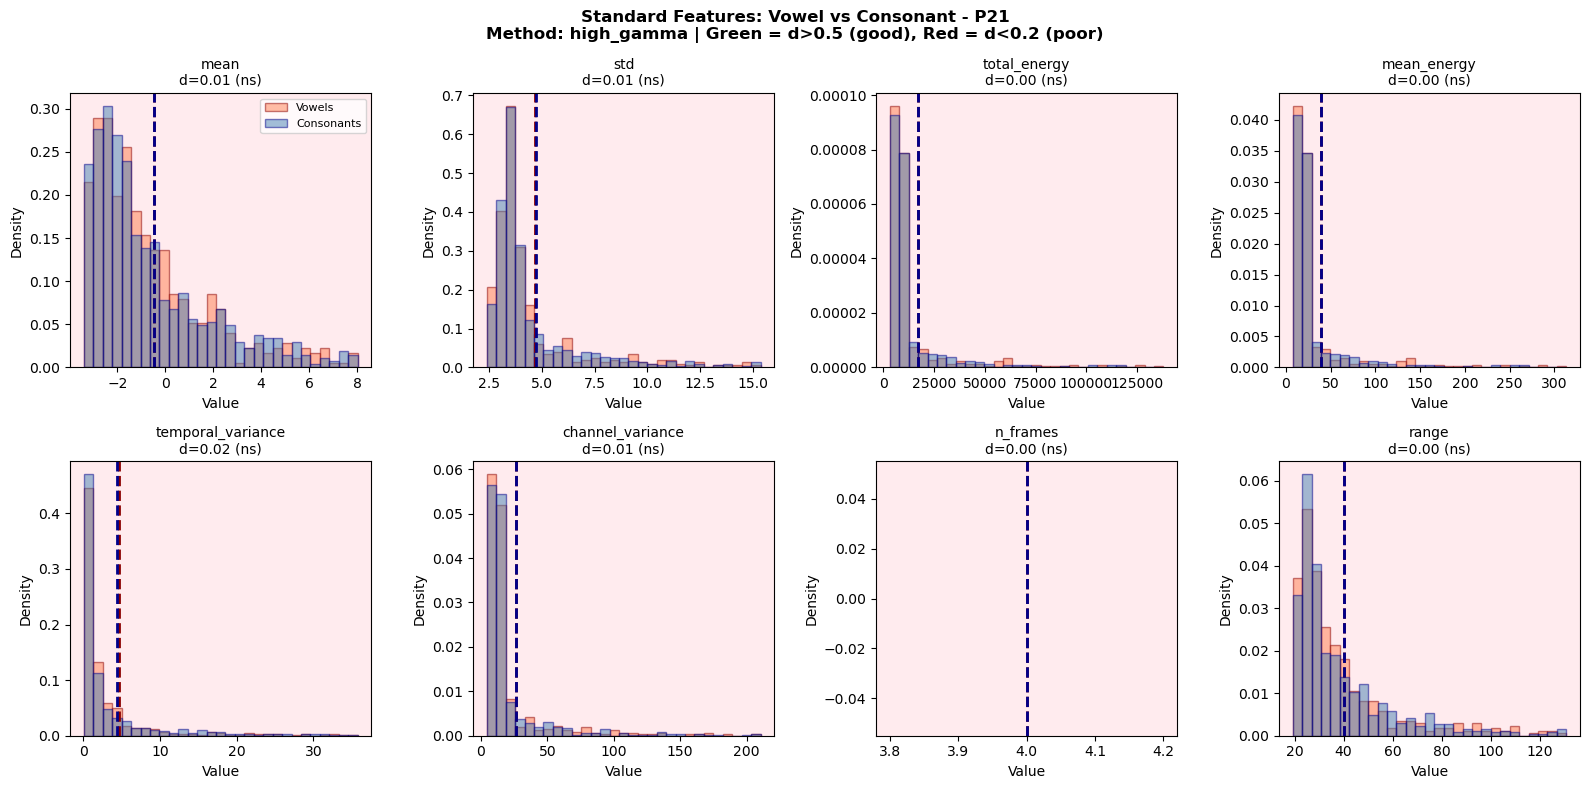

Saved: 2_transient_distributions.png


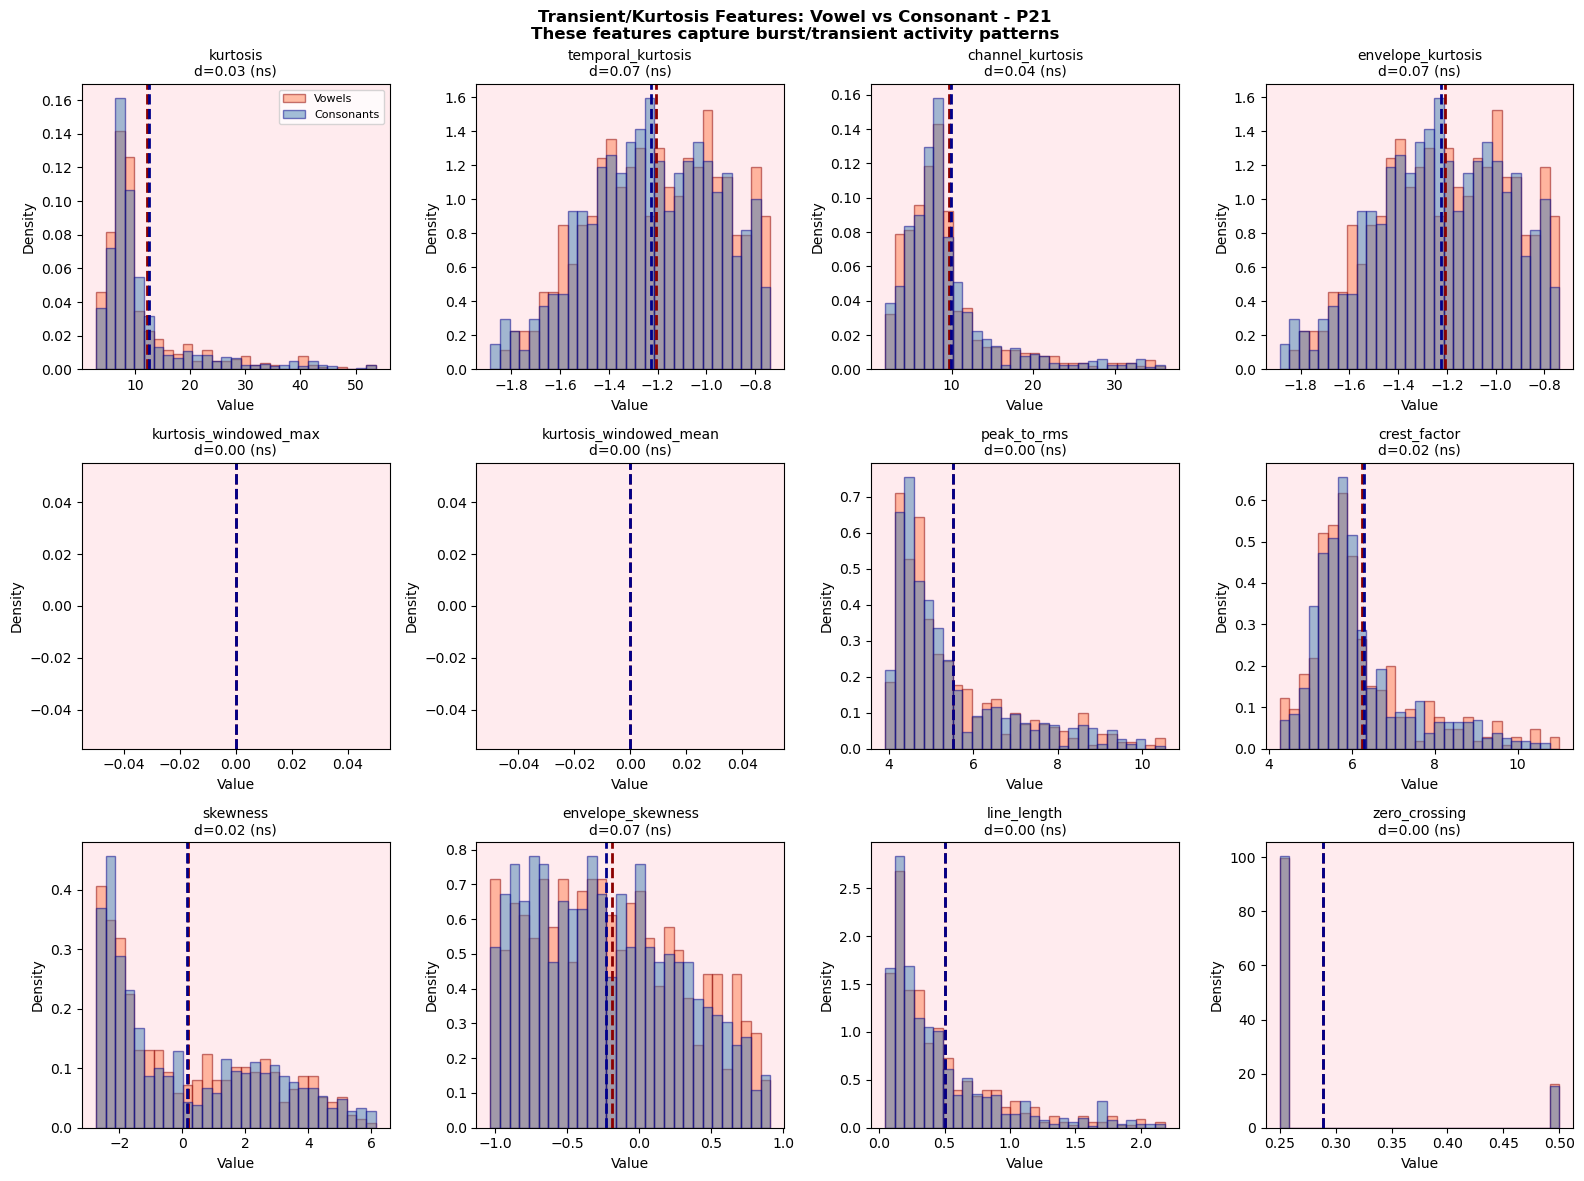

C:\Temp\ipykernel_16624\2390366310.py:589: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([std_d, trans_d], labels=['Standard', 'Transient'], patch_artist=True)


Saved: 3_separability.png


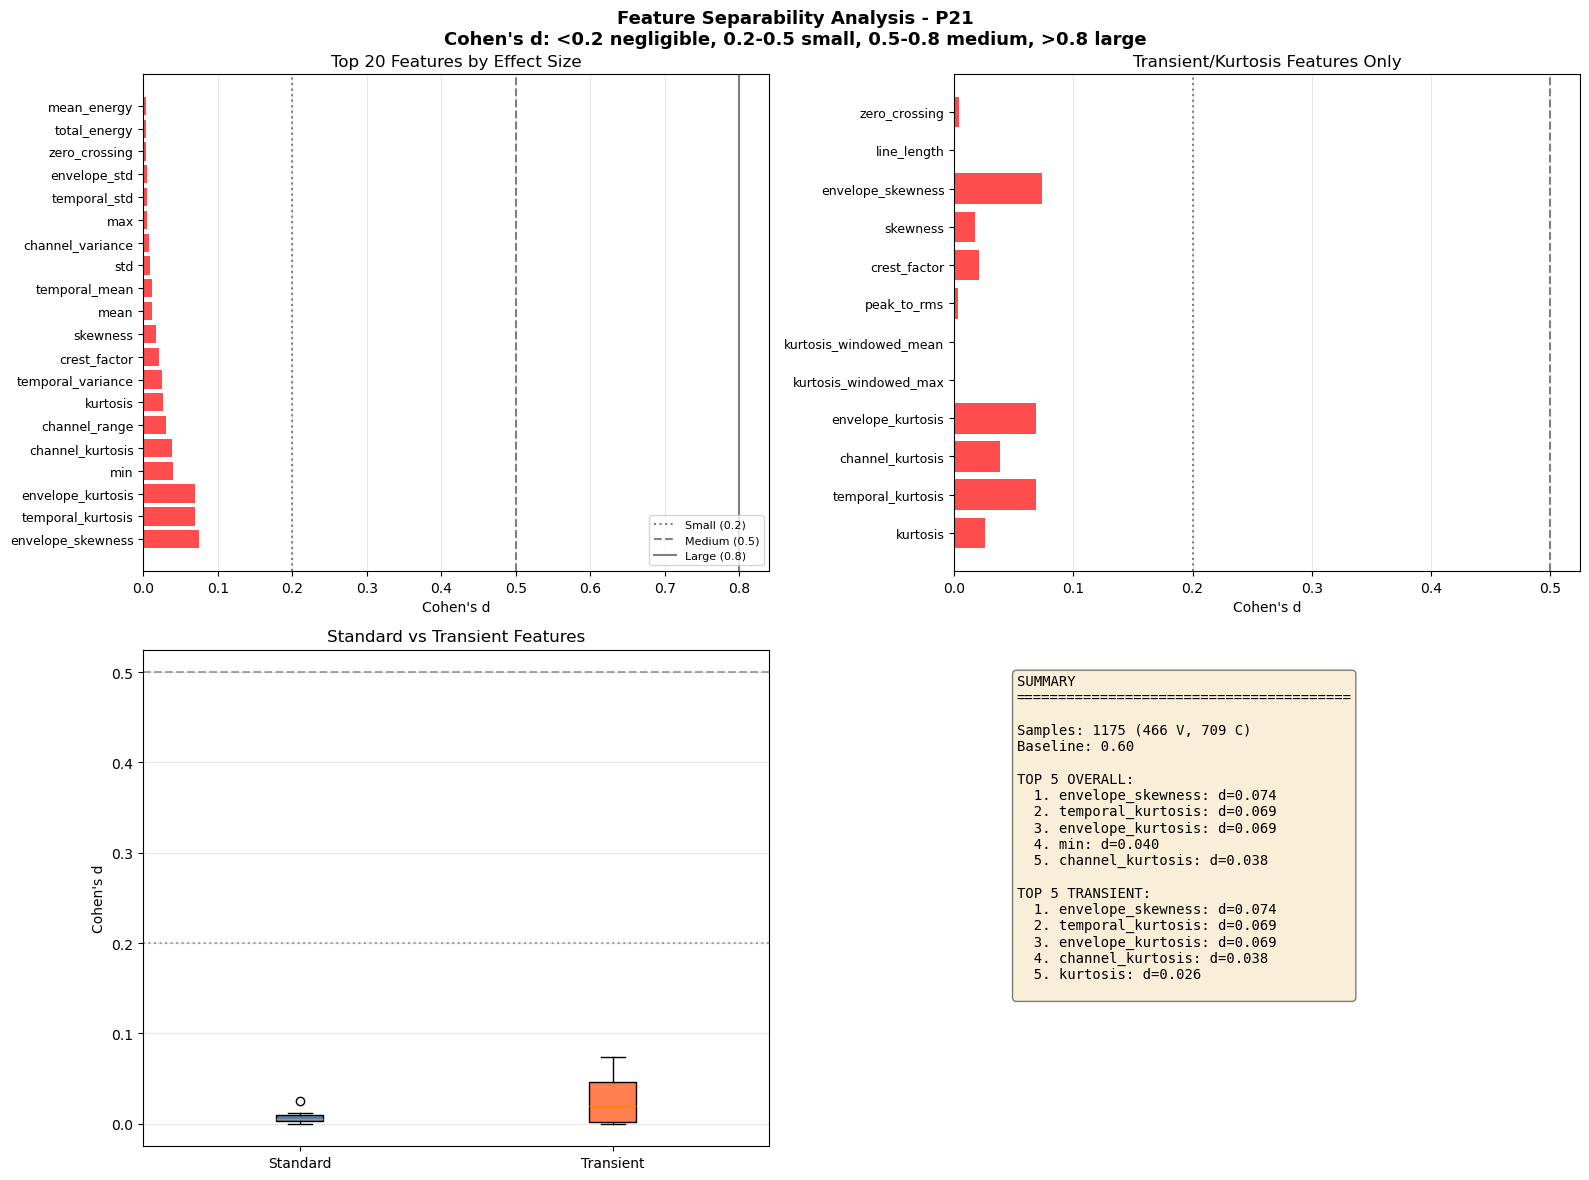

Saved: 4_phoneme_heatmap.png


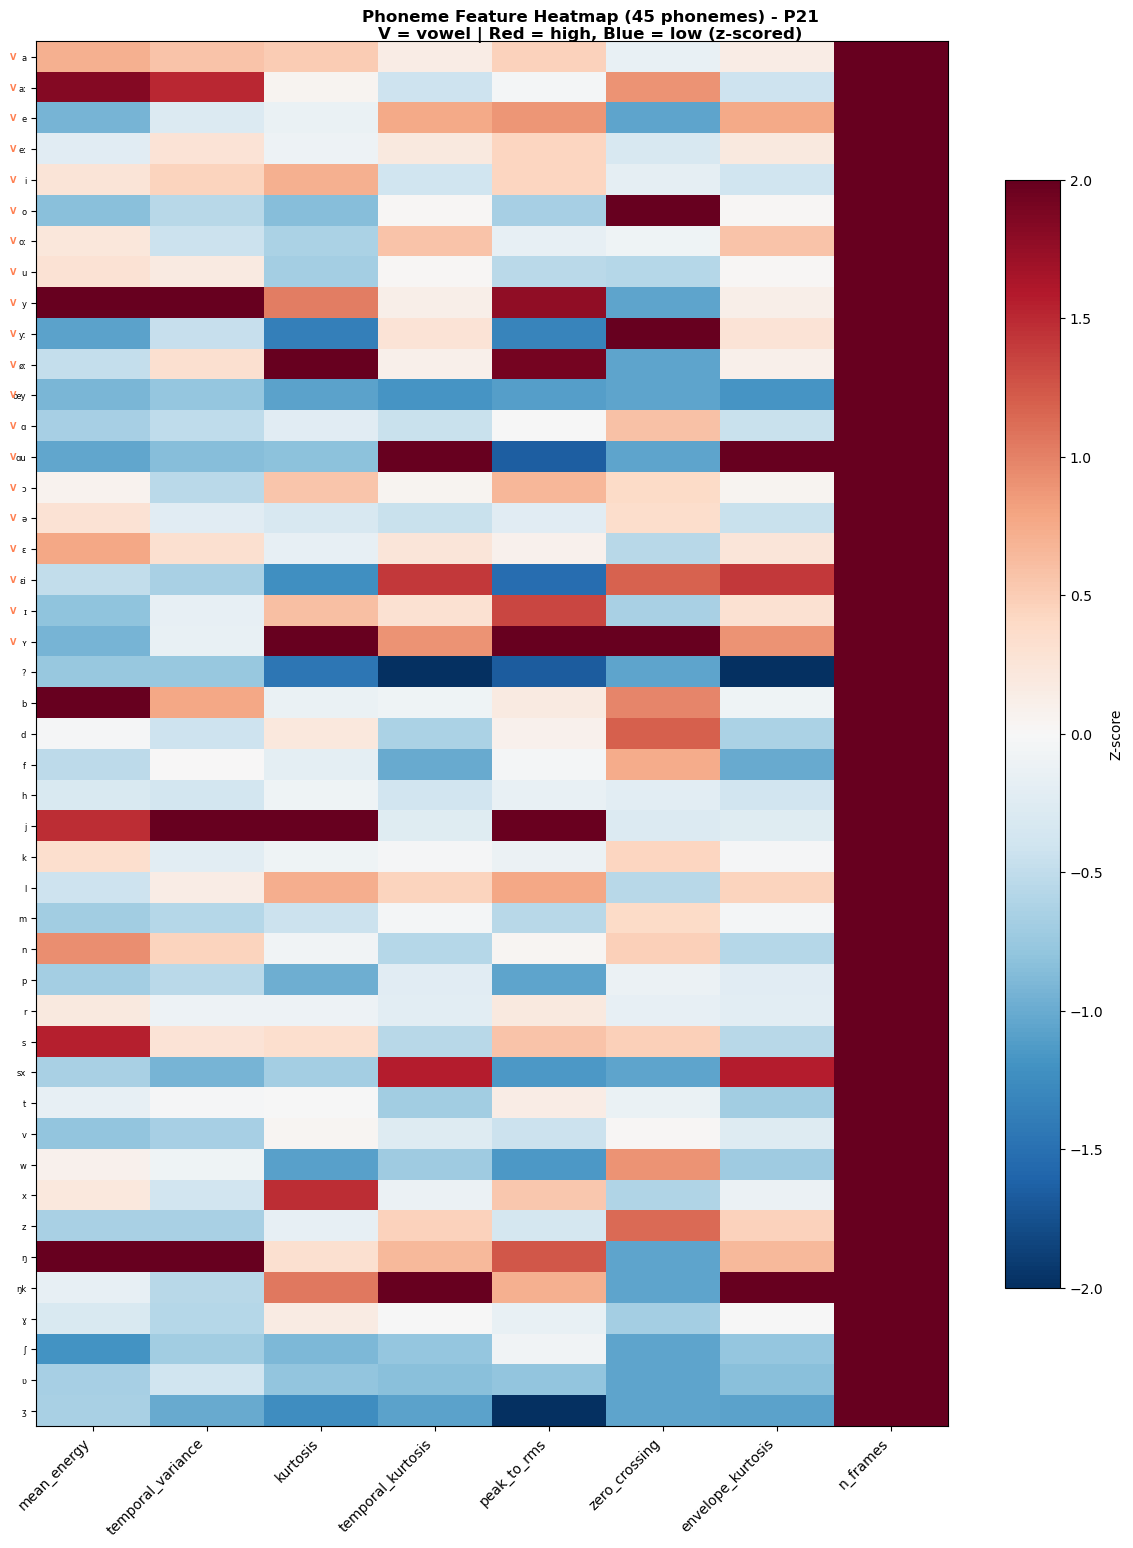


Computing learning curves...
Saved: 5_learning_curves_all.png


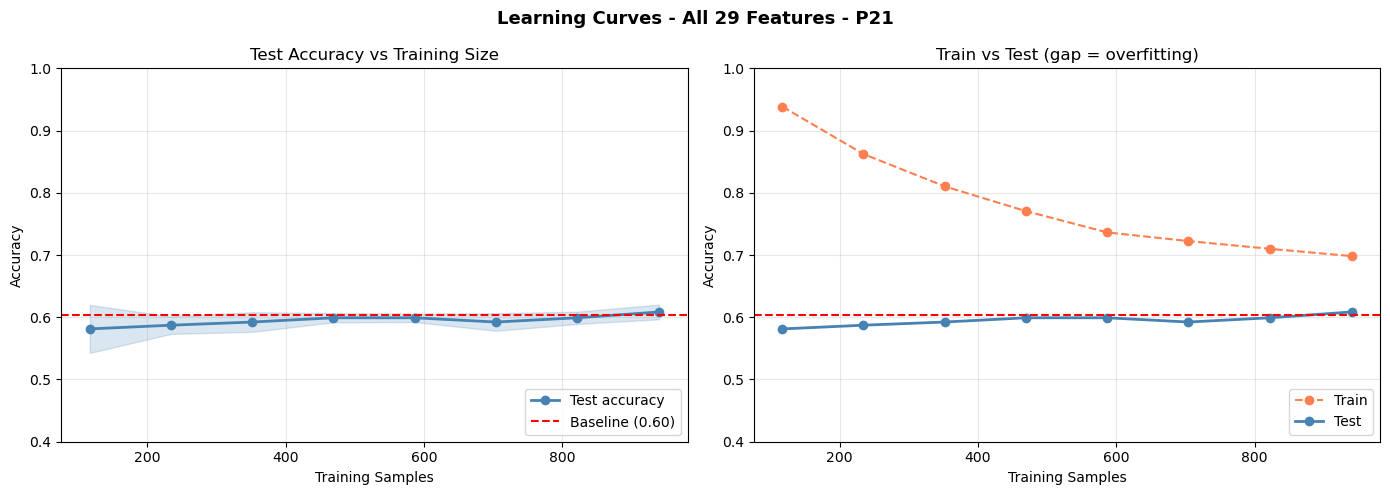


Computing feature-specific learning curves...
Saved: 6_learning_curves_features.png


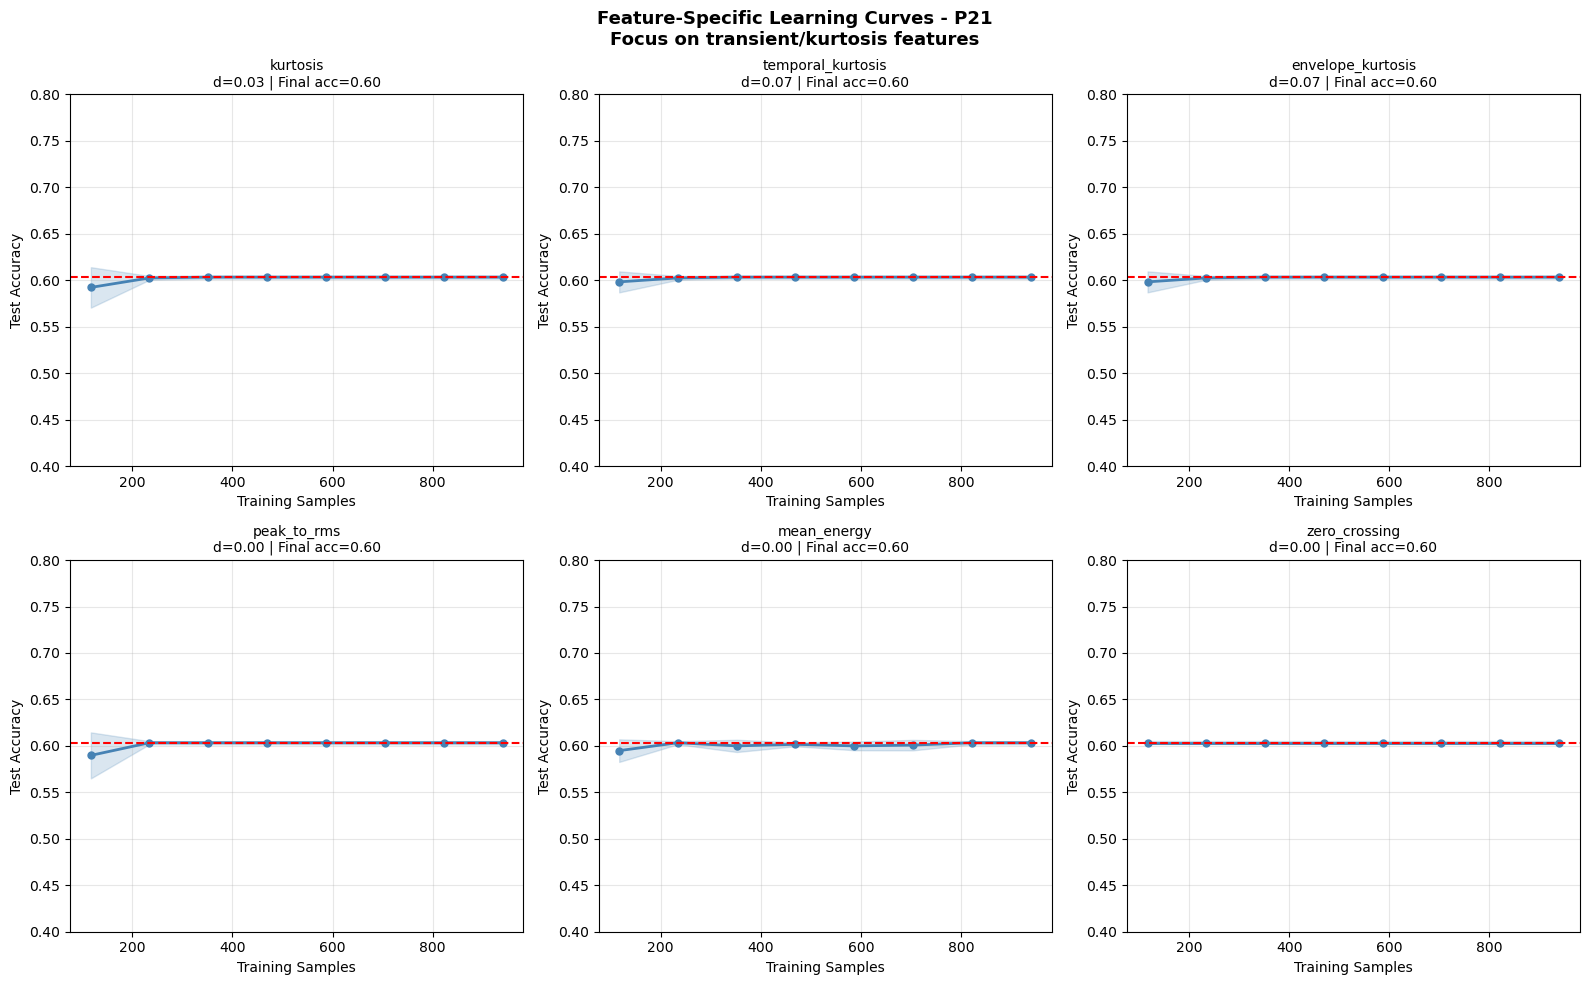


Computing feature group learning curves...
Saved: 7_learning_curves_groups.png


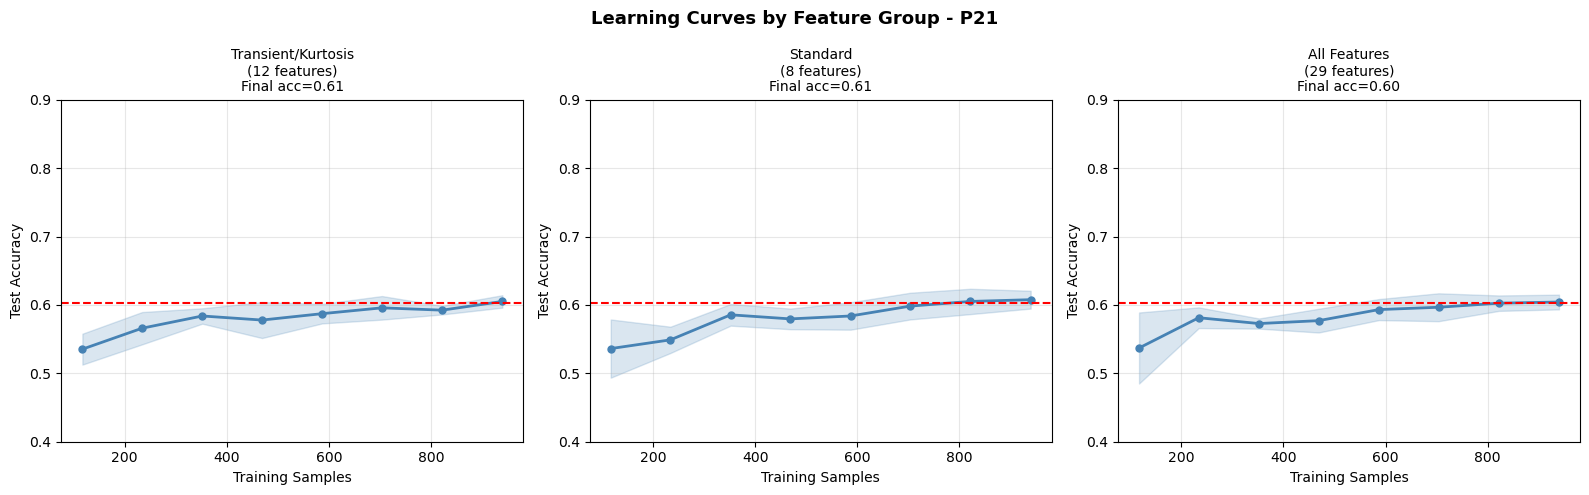


Computing dendrograms...
Saved: 8_dendrogram_overall.png


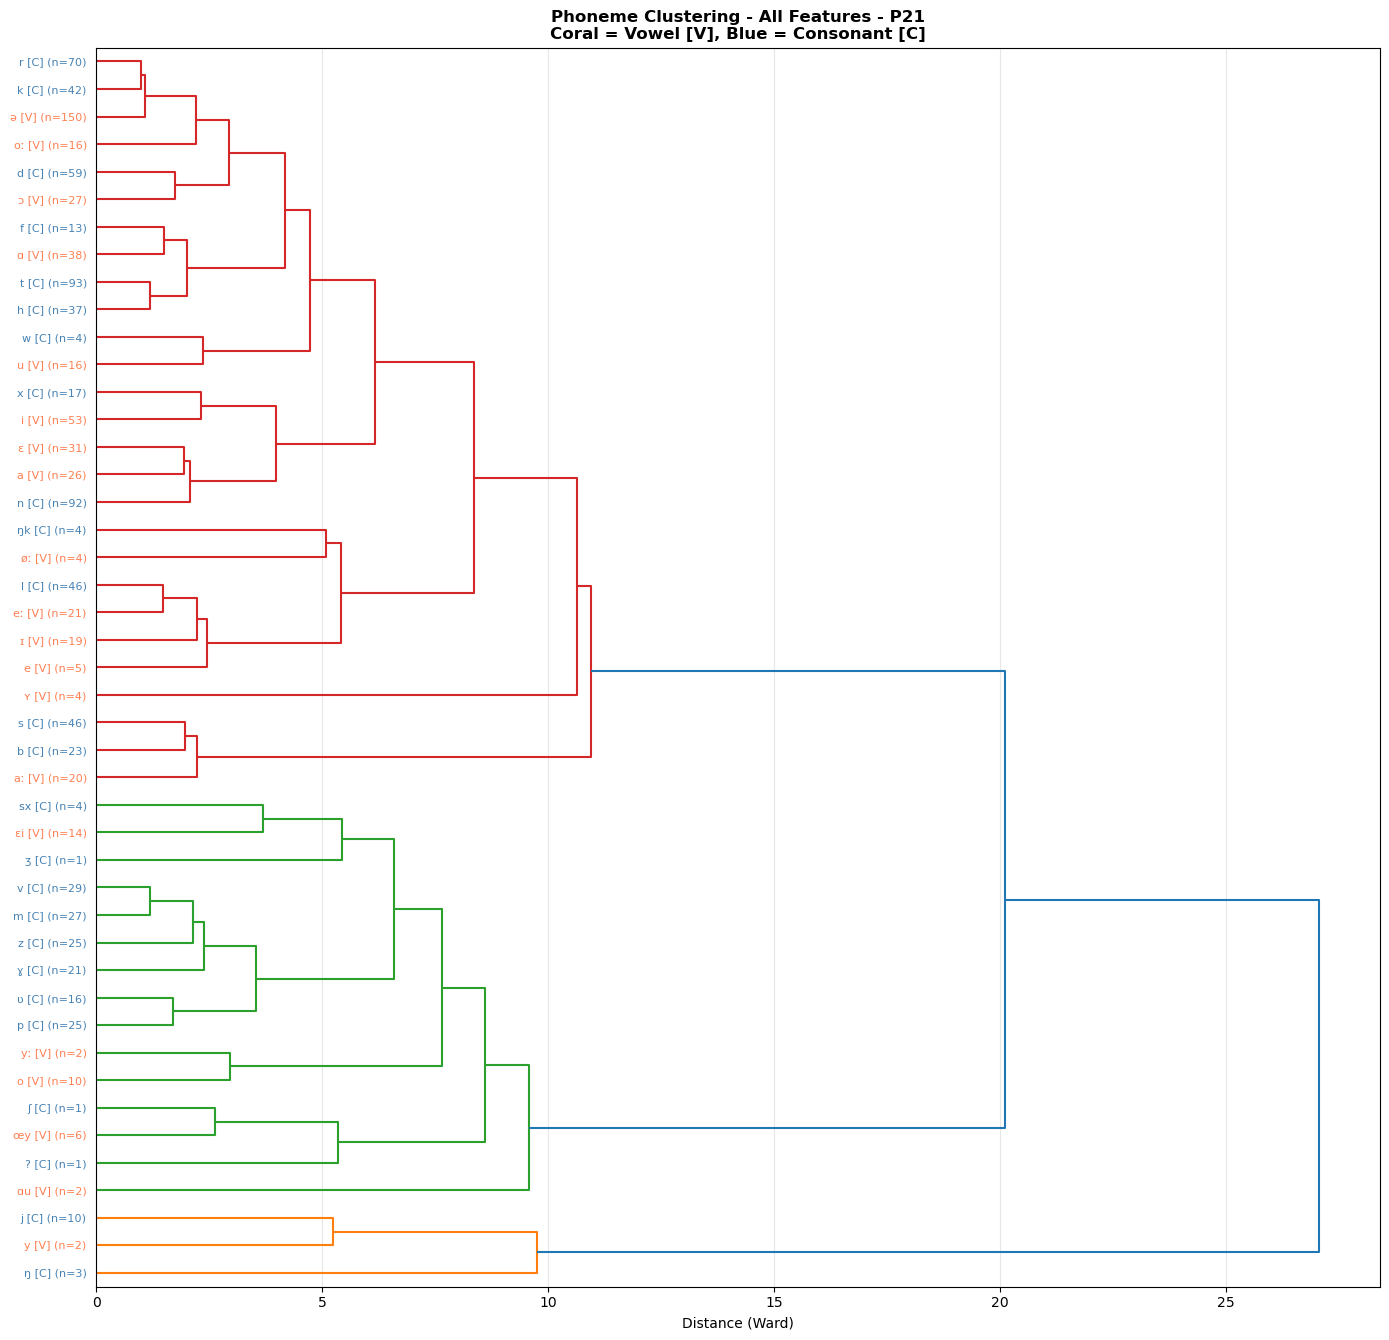

Saved: 9_dendrograms_features.png


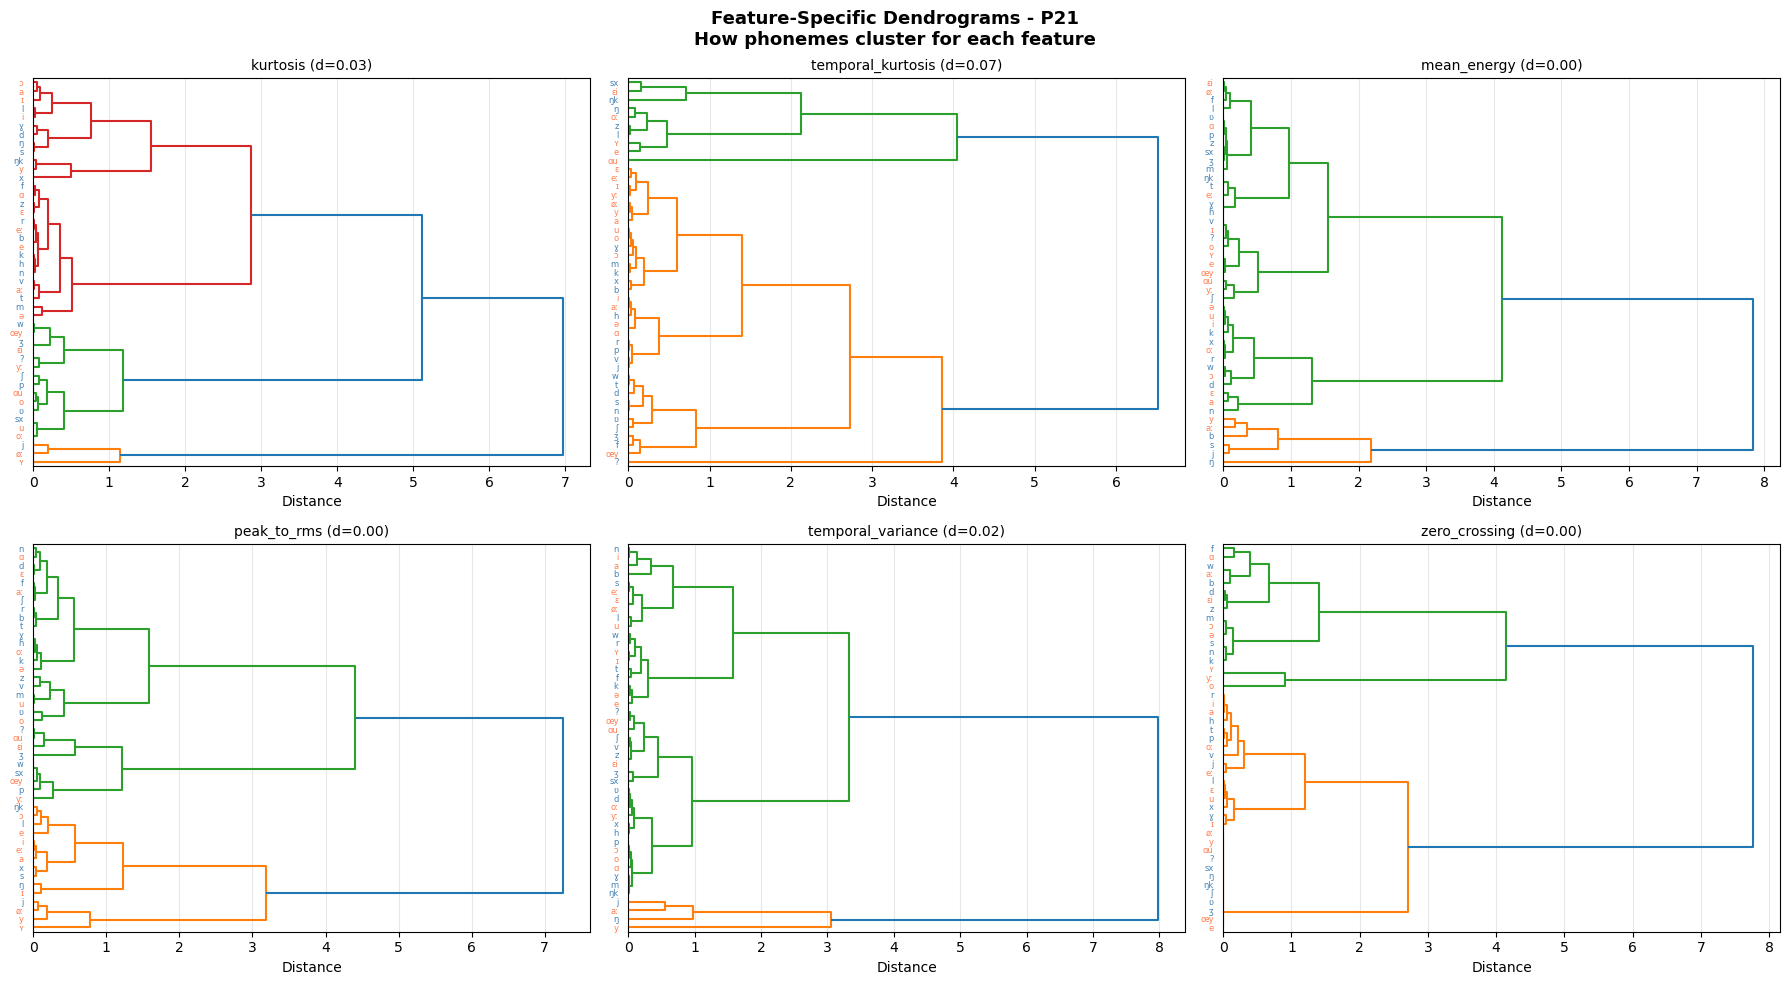

Saved: 10_cluster_quality.png


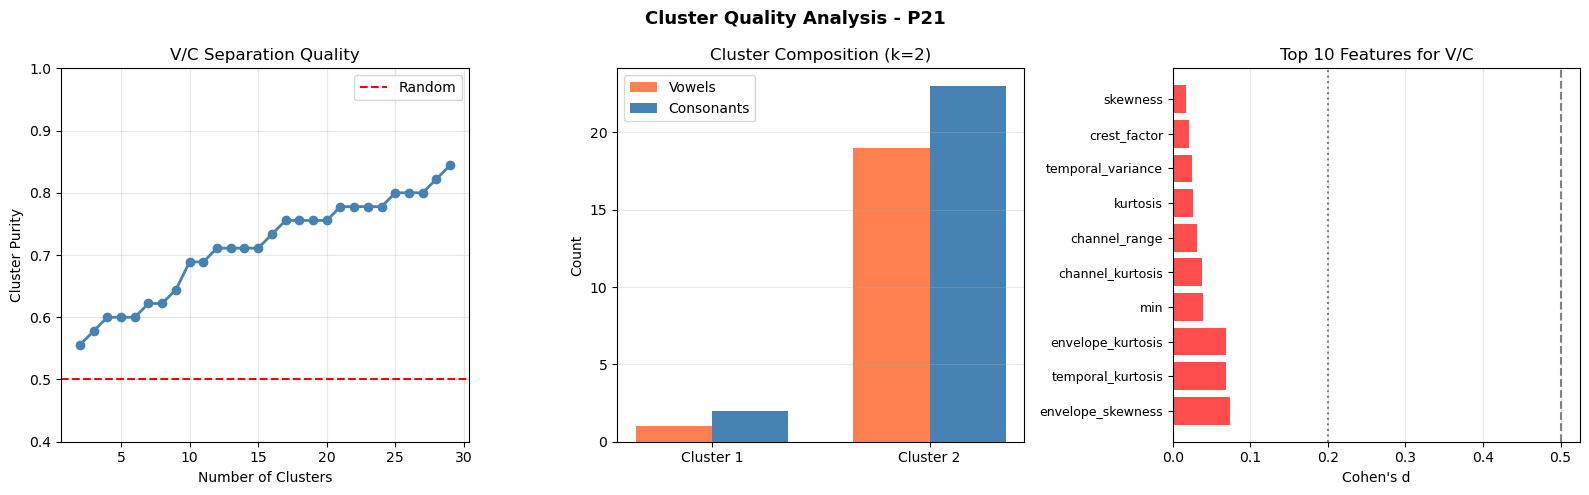


SUMMARY
Feature extraction: high_gamma
Patient: P21
Samples: 1175 (466 vowels, 709 consonants)
Phonemes: 45
Baseline: 0.60

Top 5 features overall:
  1. envelope_skewness: d=0.074
  2. temporal_kurtosis: d=0.069
  3. envelope_kurtosis: d=0.069
  4. min: d=0.040
  5. channel_kurtosis: d=0.038

Top 5 transient features:
  1. envelope_skewness: d=0.074
  2. temporal_kurtosis: d=0.069
  3. envelope_kurtosis: d=0.069
  4. channel_kurtosis: d=0.038
  5. kurtosis: d=0.026


In [30]:
results = visualize_pipeline_features(
    high_gamma_pipeline, 
    patient_id='P21',  # Or None for all patients
    save_path='./results/pipeline_analysis'
)

In [31]:
def analyze_current_results(hg_pipeline):
    """Analyze the current results after fixes."""
    
    print("="*60)
    print("ANALYZING CURRENT RESULTS")
    print("="*60)
    
    train = hg_pipeline.train
    labels = train['phoneme_labels']
    words = train['phoneme_words']
    positions = train['phoneme_positions']
    pids = train['phoneme_participant_ids']
    
    print(f"Total phonemes: {len(labels)}")
    print(f"Unknown ('?'): {labels.count('?')}")
    
    # Check for duplicate positions (sign of corruption)
    duplicate_pos = 0
    for i in range(1, len(positions)):
        if (positions[i] == positions[i-1] and 
            positions[i] != 0 and
            words[i] == words[i-1] and 
            pids[i] == pids[i-1]):
            duplicate_pos += 1
    
    print(f"Duplicate position cases: {duplicate_pos}")
    
    # Check sequence integrity for a few words
    print(f"\n--- Sample word sequences ---")
    
    phonetic_dict = hg_pipeline.phonetic_dict
    
    test_words = ['de', 'het', 'een', 'hoe', 'en']
    
    for test_word in test_words:
        expected = phonetic_dict.extract_phonemes(test_word)
        if not expected:
            continue
        
        correct = 0
        too_short = 0
        too_long = 0
        total = 0
        
        i = 0
        while i < len(labels):
            if words[i] == test_word:
                start = i
                pid = pids[i]
                
                while i < len(labels) and words[i] == test_word and pids[i] == pid:
                    if i > start and positions[i] == 0:
                        break
                    i += 1
                
                instance = list(labels[start:i])
                total += 1
                
                if instance == expected:
                    correct += 1
                elif len(instance) < len(expected):
                    too_short += 1
                else:
                    too_long += 1
            else:
                i += 1
        
        if total > 0:
            print(f"  '{test_word}' ({expected}): {correct}/{total} correct ({100*correct/total:.1f}%)")
            print(f"      Too short: {too_short}, Too long: {too_long}")


analyze_current_results(high_gamma_pipeline)

ANALYZING CURRENT RESULTS
Total phonemes: 19025
Unknown ('?'): 114
Duplicate position cases: 0

--- Sample word sequences ---
  'de' (['d', 'ə']): 174/174 correct (100.0%)
      Too short: 0, Too long: 0
  'het' (['h', 'ɛ', 't']): 63/77 correct (81.8%)
      Too short: 14, Too long: 0
  'een' (['ə', 'n']): 139/139 correct (100.0%)
      Too short: 0, Too long: 0
  'hoe' (['h', 'u']): 6/6 correct (100.0%)
      Too short: 0, Too long: 0
  'en' (['ɛ', 'n']): 27/27 correct (100.0%)
      Too short: 0, Too long: 0


In [32]:
def check_word_quality_by_patient(hg_pipeline, word='de'):
    """
    Check quality of a specific word across all patients.
    """
    
    print("="*80)
    print(f"WORD QUALITY BY PATIENT: '{word}'")
    print("="*80)
    
    phonetic_dict = hg_pipeline.phonetic_dict
    expected = phonetic_dict.extract_phonemes(word)
    
    print(f"Expected: {expected}")
    
    train_data = hg_pipeline.train
    labels = train_data['phoneme_labels']
    words = train_data['phoneme_words']
    pids = train_data['phoneme_participant_ids']
    positions = train_data['phoneme_positions']
    
    # Group instances by patient
    from collections import defaultdict
    patient_instances = defaultdict(list)
    
    i = 0
    while i < len(labels):
        if words[i] == word:
            start = i
            pid = pids[i]
            
            while i < len(labels) and words[i] == word and pids[i] == pid:
                if i > start and positions[i] == 0:
                    break
                i += 1
            
            instance_phonemes = list(labels[start:i])
            patient_instances[pid].append(instance_phonemes)
        else:
            i += 1
    
    print(f"\n{'Patient':<10} {'Total':<8} {'Correct':<10} {'Too Short':<12} {'Too Long':<10}")
    print("-"*55)
    
    for pid in sorted(patient_instances.keys()):
        instances = patient_instances[pid]
        total = len(instances)
        correct = sum(1 for inst in instances if inst == expected)
        too_short = sum(1 for inst in instances if len(inst) < len(expected))
        too_long = sum(1 for inst in instances if len(inst) > len(expected))
        
        print(f"{pid:<10} {total:<8} {correct:<10} {too_short:<12} {too_long:<10}")
        
        # Show examples of wrong ones
        wrong = [inst for inst in instances if inst != expected]
        if wrong:
            unique_wrong = list(set(tuple(w) for w in wrong))[:3]
            for w in unique_wrong:
                print(f"           -> {list(w)}")


check_word_quality_by_patient(high_gamma_pipeline, word='de')
check_word_quality_by_patient(high_gamma_pipeline, word='het')

WORD QUALITY BY PATIENT: 'de'
Expected: ['d', 'ə']

Patient    Total    Correct    Too Short    Too Long  
-------------------------------------------------------
P02        1        1          0            0         
P03        1        1          0            0         
P04        1        1          0            0         
P06        1        1          0            0         
P07        1        1          0            0         
P08        1        1          0            0         
P09        1        1          0            0         
P10        1        1          0            0         
P21        14       14         0            0         
P22        16       16         0            0         
P23        22       22         0            0         
P24        15       15         0            0         
P25        15       15         0            0         
P26        12       12         0            0         
P27        16       16         0            0         
P28        1

In [33]:
def verify_current_pipeline_results(hg_pipeline):
    """
    Quick verification of current pipeline results.
    """
    
    print("="*80)
    print("CURRENT PIPELINE RESULTS VERIFICATION")
    print("="*80)
    
    phonetic_dict = hg_pipeline.phonetic_dict
    
    train_data = hg_pipeline.train
    labels = train_data['phoneme_labels']
    words = train_data['phoneme_words']
    positions = train_data['phoneme_positions']
    pids = train_data['phoneme_participant_ids']
    
    # Quick stats
    print(f"\nTotal phonemes in train: {len(labels)}")
    print(f"Unique words: {len(set(words))}")
    print(f"Unique patients: {len(set(pids))}")
    
    # Check sequence integrity for a few words
    test_words = ['de', 'het', 'een', 'warm']
    
    for word in test_words:
        expected = phonetic_dict.extract_phonemes(word)
        
        # Count instances and check correctness
        correct = 0
        incorrect = 0
        
        i = 0
        while i < len(labels):
            if words[i] == word:
                start = i
                pid = pids[i]
                
                while i < len(labels) and words[i] == word and pids[i] == pid:
                    if i > start and positions[i] == 0:
                        break
                    i += 1
                
                instance = list(labels[start:i])
                
                if instance == expected:
                    correct += 1
                else:
                    incorrect += 1
            else:
                i += 1
        
        total = correct + incorrect
        pct = correct / total * 100 if total > 0 else 0
        print(f"\n'{word}' ({expected}): {correct}/{total} correct ({pct:.1f}%)")
    
    # Overall sequence integrity
    print("\n--- Overall Sequence Integrity ---")
    
    total_correct = 0
    total_incorrect = 0
    
    i = 0
    while i < len(labels):
        word = words[i]
        start = i
        pid = pids[i]
        
        while i < len(labels) and words[i] == word and pids[i] == pid:
            if i > start and positions[i] == 0:
                break
            i += 1
        
        instance = list(labels[start:i])
        
        if word in phonetic_dict:
            expected = phonetic_dict.extract_phonemes(word)
            if instance == expected:
                total_correct += 1
            else:
                total_incorrect += 1
    
    total = total_correct + total_incorrect
    print(f"Correct sequences: {total_correct}/{total} ({total_correct/total*100:.1f}%)")
    print(f"Incorrect sequences: {total_incorrect}/{total} ({total_incorrect/total*100:.1f}%)")


verify_current_pipeline_results(high_gamma_pipeline)

CURRENT PIPELINE RESULTS VERIFICATION

Total phonemes in train: 19025
Unique words: 1512
Unique patients: 27

'de' (['d', 'ə']): 174/174 correct (100.0%)

'het' (['h', 'ɛ', 't']): 63/77 correct (81.8%)

'een' (['ə', 'n']): 139/139 correct (100.0%)

'warm' (['ʋ', 'ɑ', 'r', 'm']): 24/24 correct (100.0%)

--- Overall Sequence Integrity ---
Correct sequences: 3285/3807 (86.3%)
Incorrect sequences: 522/3807 (13.7%)


In [34]:
def diagnose_duplicate_positions(hg_pipeline):
    """
    Understand what's causing duplicate positions.
    """
    
    print("="*80)
    print("DIAGNOSING DUPLICATE POSITIONS")
    print("="*80)
    
    train = hg_pipeline.train
    labels = train['phoneme_labels']
    positions = train['phoneme_positions']
    words = train['phoneme_words']
    pids = train['phoneme_participant_ids']
    
    # Find and show context around duplicate positions
    print("\n--- Examples of duplicate position contexts ---")
    
    shown = 0
    
    for i in range(1, len(positions)):
        if (positions[i] == positions[i-1] and 
            positions[i] != 0 and
            words[i] == words[i-1] and 
            pids[i] == pids[i-1]):
            
            if shown < 10:
                # Show context: 3 before and 3 after
                start = max(0, i - 3)
                end = min(len(positions), i + 4)
                
                print(f"\n--- Context around index {i} ---")
                print(f"{'Idx':<6} {'Word':<15} {'Patient':<8} {'Pos':<5} {'Label':<6}")
                print("-" * 45)
                
                for j in range(start, end):
                    marker = ">>>" if j == i or j == i-1 else "   "
                    print(f"{marker}{j:<3} {words[j]:<15} {pids[j]:<8} {positions[j]:<5} {labels[j]:<6}")
                
                shown += 1
    
    # Check if this is from phonemes being dropped
    print(f"\n{'='*60}")
    print("CHECKING IF DROPPED PHONEMES CAUSE POSITION ISSUES")
    print(f"{'='*60}")
    
    # Look at 'nee' from P11 specifically
    print("\n--- P11/'nee' analysis ---")
    
    phonetic_dict = hg_pipeline.phonetic_dict
    expected_nee = phonetic_dict.extract_phonemes('nee')
    print(f"Expected 'nee': {expected_nee}")
    
    # Find all P11/'nee' instances
    i = 0
    while i < len(labels):
        if words[i] == 'nee' and pids[i] == 'P11':
            start = i
            
            while i < len(labels) and words[i] == 'nee' and pids[i] == 'P11':
                if i > start and positions[i] == 0:
                    break
                i += 1
            
            inst_labels = list(labels[start:i])
            inst_positions = list(positions[start:i])
            
            print(f"  Instance: {inst_labels} pos={inst_positions}")
        else:
            i += 1


diagnose_duplicate_positions(high_gamma_pipeline)

DIAGNOSING DUPLICATE POSITIONS

--- Examples of duplicate position contexts ---

CHECKING IF DROPPED PHONEMES CAUSE POSITION ISSUES

--- P11/'nee' analysis ---
Expected 'nee': ['n', 'eː']
  Instance: ['n', 'eː'] pos=[0, 1]
  Instance: ['n', 'eː'] pos=[0, 1]
  Instance: ['n', 'eː'] pos=[0, 1]


In [ ]:
def diagnose_drop_reasons(hg_pipeline):
    """Diagnose why so many instances are being dropped."""
    
    print("="*60)
    print("DIAGNOSING DROP REASONS")
    print("="*60)
    
    split_result = hg_pipeline.split_result
    word_segments_dict = split_result['word_segments_dict']
    detector = hg_pipeline.detector
    config = hg_pipeline.config
    
    # Track drop reasons
    drop_reasons = {
        'drop_word_flag': 0,
        'mismatch': 0,
        'not_in_dict': 0,
        'spectrogram_none': 0,
        'spectrogram_short': 0,
        'kept': 0
    }
    
    # Sample some instances
    tested = 0
    max_test = 200
    
    for pid in split_result['train']:
        if pid not in word_segments_dict:
            continue
        for word, indices in split_result['train'][pid].items():
            for idx in indices:
                if tested >= max_test:
                    break
                
                word_data = word_segments_dict[pid]['words'][word]['instances'][idx]
                spec = word_data.get('spectrogram_segment')
                audio = word_data.get('audio_segment')
                
                # Check spectrogram
                if spec is None:
                    drop_reasons['spectrogram_none'] += 1
                    tested += 1
                    continue
                
                if spec.shape[0] < 3:
                    drop_reasons['spectrogram_short'] += 1
                    tested += 1
                    continue
                
                # Check dictionary
                if word not in detector.phonetic_dict:
                    drop_reasons['not_in_dict'] += 1
                    tested += 1
                    continue
                
                # Try detect_boundaries
                result = detector.detect_boundaries(
                    spectrogram=spec,
                    word=word,
                    participant_id=pid,
                    word_position=0,
                    use_multifeature=detector.use_multifeature,
                    use_rms_boundaries=detector.use_rms_boundaries,
                    audio_segment=audio,
                    audio_sr=config.audio_sr
                )
                
                if result.get('drop_word', False):
                    drop_reasons['drop_word_flag'] += 1
                    if tested < 10:
                        print(f"  DROP: {pid}/{word} - {result.get('reason', '?')}")
                    tested += 1
                    continue
                
                # Check segment/phoneme match
                segments = result['segments']
                expected_phonemes = detector.phonetic_dict.extract_phonemes(word)
                
                if len(segments) != len(expected_phonemes):
                    drop_reasons['mismatch'] += 1
                    if tested < 20:
                        print(f"  MISMATCH: {pid}/{word} - {len(segments)} segments vs {len(expected_phonemes)} phonemes")
                    tested += 1
                    continue
                
                drop_reasons['kept'] += 1
                tested += 1
            
            if tested >= max_test:
                break
        if tested >= max_test:
            break
    
    print(f"\n--- Drop Reasons (n={tested}) ---")
    for reason, count in sorted(drop_reasons.items(), key=lambda x: -x[1]):
        print(f"  {reason}: {count} ({100*count/tested:.1f}%)")


diagnose_drop_reasons(high_gamma_pipeline)

In [41]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import kurtosis, skew
from collections import Counter, defaultdict


def linguistic_syllable_extraction(hg_pipeline):
    """
    Proper linguistic syllable extraction:
    - Syllable = onset (0+ consonants) + nucleus (vowel/diphthong) + coda (0+ consonants)
    - Split at syllable boundaries: before onset of next syllable
    - Patterns: V, CV, CCV, CCCV, VC, CVC, CCVC, CVCC, etc.
    """
    
    # Dutch vowels and diphthongs
    vowels = {'i', 'ɪ', 'e', 'ɛ', 'y', 'ʏ', 'ø', 'u', 'ʊ', 'o', 'ɔ', 'a', 'ɑ', 'ə',
              'iː', 'eː', 'yː', 'øː', 'uː', 'oː', 'aː', 'ɑː'}
    
    # Dutch diphthongs (counted as single nucleus)
    diphthongs = {'ɛi', 'œy', 'ɑu', 'ai', 'oi', 'ui', 'ei', 'au', 'ou', 'eu', 'iu'}
    
    def is_vowel(phoneme):
        return phoneme in vowels
    
    def extract_word_syllables(phonemes):
        """
        Extract syllables from a phoneme sequence.
        
        Strategy:
        1. Find all vowel positions (nuclei)
        2. Assign consonants to syllables using Maximum Onset Principle:
           - Consonants between vowels go to the following syllable (as onset)
           - Unless that would leave the previous syllable without a coda when needed
        """
        if not phonemes:
            return []
        
        # Find vowel positions
        vowel_positions = [i for i, p in enumerate(phonemes) if is_vowel(p)]
        
        if not vowel_positions:
            return []  # No vowels = no syllables
        
        syllables = []
        
        for v_idx, v_pos in enumerate(vowel_positions):
            # Find syllable boundaries
            
            # Start: after previous vowel, or start of word
            if v_idx == 0:
                start = 0
            else:
                prev_v_pos = vowel_positions[v_idx - 1]
                # Consonants between previous vowel and this one
                # Use Maximum Onset Principle: give consonants to this syllable
                # But keep at least one consonant with previous syllable if there are 2+
                consonants_between = v_pos - prev_v_pos - 1
                
                if consonants_between == 0:
                    start = v_pos  # Vowel-vowel: this syllable starts at vowel
                elif consonants_between == 1:
                    start = prev_v_pos + 1  # One consonant: give to this syllable
                else:
                    # Multiple consonants: split them
                    # Dutch typically allows complex onsets, give most to onset
                    # Keep 1 with previous syllable (as coda), rest go to this onset
                    start = prev_v_pos + 2  # prev_vowel + 1 coda + onset starts here
            
            # End: before next vowel's onset, or end of word
            if v_idx == len(vowel_positions) - 1:
                end = len(phonemes)  # Include all remaining consonants as coda
            else:
                next_v_pos = vowel_positions[v_idx + 1]
                consonants_after = next_v_pos - v_pos - 1
                
                if consonants_after == 0:
                    end = v_pos + 1  # Just the vowel
                elif consonants_after == 1:
                    end = v_pos + 1  # Consonant goes to next syllable
                else:
                    # Keep one consonant as coda
                    end = v_pos + 2
            
            syllable_phonemes = phonemes[start:end]
            
            # Classify structure
            onset = []
            nucleus = []
            coda = []
            
            state = 'onset'
            for p in syllable_phonemes:
                if state == 'onset':
                    if is_vowel(p):
                        nucleus.append(p)
                        state = 'nucleus'
                    else:
                        onset.append(p)
                elif state == 'nucleus':
                    if is_vowel(p):
                        nucleus.append(p)  # Diphthong or hiatus
                    else:
                        coda.append(p)
                        state = 'coda'
                elif state == 'coda':
                    coda.append(p)
            
            # Create structure label
            onset_str = 'C' * len(onset)
            nucleus_str = 'V' * len(nucleus)
            coda_str = 'C' * len(coda)
            structure = onset_str + nucleus_str + coda_str
            
            syllables.append({
                'phonemes': syllable_phonemes,
                'syllable': ''.join(syllable_phonemes),
                'onset': onset,
                'nucleus': nucleus,
                'coda': coda,
                'structure': structure,
                'start': start,
                'end': end,
            })
        
        return syllables
    
    # Test on specific words first
    print("="*80)
    print("LINGUISTIC SYLLABLE EXTRACTION")
    print("="*80)
    
    # Test words
    test_words = {
        'terugvinden': ['t', 'ə', 'r', 'ʏ', 'x', 'v', 'ɪ', 'n', 'd', 'ə', 'n'],
        'betovering': ['b', 'ə', 't', 'oː', 'v', 'ə', 'r', 'ɪ', 'ŋ'],
        'noordenwind': ['n', 'oː', 'r', 'd', 'ə', 'n', 'v', 'ɪ', 'n', 't'],
        'vogeltje': ['v', 'oː', 'ɣ', 'ə', 'l', 't', 'j', 'ə'],
        'morgens': ['m', 'ɔ', 'r', 'ɣ', 'ə', 'n', 's'],
        'de': ['d', 'ə'],
        'een': ['ə', 'n'],
        'het': ['h', 'ɛ', 't'],
        'bakker': ['b', 'ɑ', 'k', 'ə', 'r'],
        'straat': ['s', 't', 'r', 'aː', 't'],
    }
    
    print("\n--- EXAMPLE SYLLABIFICATIONS ---")
    for word, phonemes in test_words.items():
        syllables = extract_word_syllables(phonemes)
        phonemes_str = '-'.join(phonemes)
        syls_str = ' | '.join([f"{s['syllable']} ({s['structure']})" for s in syllables])
        print(f"\n'{word}' [{phonemes_str}]:")
        print(f"  -> {syls_str}")
    
    # Now extract from actual data
    print("\n" + "="*80)
    print("EXTRACTING FROM PIPELINE DATA")
    print("="*80)
    
    def extract_syllables_from_data(data, within_word_only=True):
        """Extract syllables from pipeline data."""
        labels = data['phoneme_labels']
        features = data['features']
        pids = data['phoneme_participant_ids']
        words = data.get('phoneme_words', [None] * len(labels))
        
        syllable_data = []
        
        # Group phonemes by word instance
        i = 0
        while i < len(labels):
            if words[i] is None:
                i += 1
                continue
            
            # Find word span
            word = words[i]
            start = i
            while i < len(labels) and words[i] == word:
                i += 1
            end = i
            
            word_phonemes = list(labels[start:end])
            word_features = list(features[start:end])
            word_patient = pids[start]
            
            # Extract syllables
            syllables = extract_word_syllables(word_phonemes)
            
            for syl in syllables:
                syl_start = start + syl['start']
                syl_end = start + syl['end']
                syl_features = word_features[syl['start']:syl['end']]
                
                # Skip if any features are None
                if any(f is None for f in syl_features):
                    continue
                
                syllable_data.append({
                    'syllable': syl['syllable'],
                    'structure': syl['structure'],
                    'onset': ''.join(syl['onset']),
                    'nucleus': ''.join(syl['nucleus']),
                    'coda': ''.join(syl['coda']),
                    'phonemes': syl['phonemes'],
                    'features': syl_features,
                    'patient': word_patient,
                    'word': word,
                    'word_phonemes': word_phonemes,
                    'position': syl['start'],
                    'position_str': f"{syl['start']}/{len(word_phonemes)}",
                })
        
        return syllable_data
    
    train_data = extract_syllables_from_data(hg_pipeline.train)
    test_data = extract_syllables_from_data(hg_pipeline.test)
    
    print(f"\nExtracted:")
    print(f"  Train: {len(train_data)} syllables")
    print(f"  Test: {len(test_data)} syllables")
    
    # Analyze structures
    print(f"\n--- SYLLABLE STRUCTURES ---")
    train_structures = Counter([s['structure'] for s in train_data])
    print(f"\nTop structures:")
    for struct, count in train_structures.most_common(15):
        examples = [s['syllable'] for s in train_data if s['structure'] == struct][:5]
        print(f"  {struct}: {count} (e.g., {', '.join(examples)})")
    
    # Top syllables
    print(f"\n--- TOP SYLLABLES ---")
    syllable_counts = Counter([s['syllable'] for s in train_data])
    print(f"\nTop 20:")
    for syl, count in syllable_counts.most_common(20):
        # Get structure
        example = [s for s in train_data if s['syllable'] == syl][0]
        print(f"  {syl} ({example['structure']}): {count}")
    
    # Show examples from specific words
    print(f"\n--- SYLLABLES FROM SPECIFIC WORDS ---")
    
    for target in ['terugvinden', 'betovering', 'noordenwind', 'de', 'een', 'morgens']:
        print(f"\n'{target}':")
        
        for name, data in [('TRAIN', train_data), ('TEST', test_data)]:
            word_syls = [s for s in data if s['word'] and s['word'].lower() == target.lower()]
            
            if word_syls:
                # Group by occurrence
                by_phonemes = defaultdict(list)
                for s in word_syls:
                    by_phonemes[tuple(s['word_phonemes'])].append(s)
                
                print(f"  {name}:")
                for phonemes, syls in list(by_phonemes.items())[:2]:
                    phonemes_str = '-'.join(phonemes)
                    syls_sorted = sorted(syls, key=lambda x: x['position'])
                    syls_str = ' | '.join([f"{s['syllable']}({s['structure']})@{s['position']}" for s in syls_sorted])
                    print(f"    [{phonemes_str}]: {syls_str}")
    
    return train_data, test_data, extract_word_syllables


# Run extraction
train_data, test_data, extract_fn = linguistic_syllable_extraction(high_gamma_pipeline)

LINGUISTIC SYLLABLE EXTRACTION

--- EXAMPLE SYLLABIFICATIONS ---

'terugvinden' [t-ə-r-ʏ-x-v-ɪ-n-d-ə-n]:
  -> tə (CV) | rʏx (CVC) | vɪn (CVC) | dən (CVC)

'betovering' [b-ə-t-oː-v-ə-r-ɪ-ŋ]:
  -> bə (CV) | toː (CV) | və (CV) | rɪŋ (CVC)

'noordenwind' [n-oː-r-d-ə-n-v-ɪ-n-t]:
  -> noːr (CVC) | dən (CVC) | vɪnt (CVCC)

'vogeltje' [v-oː-ɣ-ə-l-t-j-ə]:
  -> voː (CV) | ɣəl (CVC) | tjə (CCV)

'morgens' [m-ɔ-r-ɣ-ə-n-s]:
  -> mɔr (CVC) | ɣəns (CVCC)

'de' [d-ə]:
  -> də (CV)

'een' [ə-n]:
  -> ən (VC)

'het' [h-ɛ-t]:
  -> hɛt (CVC)

'bakker' [b-ɑ-k-ə-r]:
  -> bɑ (CV) | kər (CVC)

'straat' [s-t-r-aː-t]:
  -> straːt (CCCVC)

EXTRACTING FROM PIPELINE DATA

Extracted:
  Train: 894 syllables
  Test: 470 syllables

--- SYLLABLE STRUCTURES ---

Top structures:
  CV: 391 (e.g., dɑ, di, ty, də, di)
  CVC: 274 (e.g., pəl, kər, zɑn, dɑk, ʋit)
  V: 69 (e.g., oː, oː, ə, ɛ, ɪ)
  VC: 67 (e.g., ik, ɪk, ɪn, ɛr, ər)
  CVCC: 32 (e.g., ʋɛrt, rɛkt, rɛkt, mɔnt, word)
  CCV: 16 (e.g., bra, ski, stu, ɣru, vli)
  CCVC: 

In [ ]:
def analyze_all_patients(pipeline, patient_ids=None, save_path=None):
    """
    Loop through all patients and extract key metrics from feature analysis.
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_ids: List of patient IDs to analyze, or None for all
        save_path: Directory to save results
    
    Returns:
        dict: Contains DataFrames with patient summaries, feature rankings, etc.
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    import os
    import warnings
    warnings.filterwarnings('ignore')
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get all patient IDs if not specified
    all_participant_ids = train_data['phoneme_participant_ids']
    if patient_ids is None:
        patient_ids = sorted(set(all_participant_ids))
    
    print(f"Analyzing {len(patient_ids)} patients: {patient_ids}")
    
    # Define vowels
    vowels = {
        'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
        'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
        'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
        'ɛi', 'œy', 'ɑu', 'ʌu',
    }
    
    # ========================================================================
    # FEATURE EXTRACTION FUNCTION
    # ========================================================================
    
    def extract_summary_features(feat):
        """Extract summary statistics from pipeline feature matrix."""
        if feat is None or feat.size == 0:
            return None
        
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        summary = {}
        
        if n_frames == 1:
            signal = feat.flatten()
        else:
            signal = feat.flatten()
        
        # Basic statistics
        summary['mean'] = np.mean(signal)
        summary['std'] = np.std(signal)
        summary['max'] = np.max(signal)
        summary['min'] = np.min(signal)
        summary['range'] = summary['max'] - summary['min']
        
        # Energy features
        summary['total_energy'] = np.sum(signal ** 2)
        summary['mean_energy'] = np.mean(signal ** 2)
        
        # Distribution features
        summary['channel_variance'] = np.var(signal)
        
        # Kurtosis and skewness
        if len(signal) > 3:
            kurt_val = kurtosis(signal, nan_policy='omit')
            summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
            
            skew_val = skew(signal, nan_policy='omit')
            summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
        else:
            summary['kurtosis'] = 0
            summary['skewness'] = 0
        
        # Peak features
        rms = np.sqrt(np.mean(signal ** 2))
        summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
        summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
        
        # Line length and zero crossing
        summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
        centered = signal - np.mean(signal)
        summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
    
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    # ========================================================================
    # ANALYZE EACH PATIENT
    # ========================================================================
    
    # Storage for results
    patient_summaries = []
    feature_rankings = []
    phoneme_counts = []
    classification_results = []
    
    for pid in patient_ids:
        print(f"\nAnalyzing {pid}...")
        
        # Filter data for this patient
        indices = [i for i, p in enumerate(all_participant_ids) if p == pid]
        
        if not indices:
            print(f"  No data for {pid}")
            continue
        
        features_list = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        # Extract summary features
        summaries = []
        valid_indices = []
        
        for i, feat in enumerate(features_list):
            s = extract_summary_features(feat)
            if s is not None:
                summaries.append(s)
                valid_indices.append(i)
        
        if len(summaries) == 0:
            print(f"  No valid features for {pid}")
            continue
        
        # Filter labels
        labels = [labels[i] for i in valid_indices]
        
        # Get feature names and create matrix
        feature_names = list(summaries[0].keys())
        X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
        # Create binary labels
        is_vowel = [1 if label in vowels else 0 for label in labels]
        y = np.array(is_vowel)
        
        n_vowels = sum(y)
        n_consonants = len(y) - n_vowels
        n_phonemes = len(set(labels))
        baseline = max(n_vowels, n_consonants) / len(y)
        
        # ================================================================
        # COMPUTE FEATURE STATISTICS
        # ================================================================
        
        feature_stats = {}
        for i, feat_name in enumerate(feature_names):
            vowel_vals = X[y == 1, i]
            cons_vals = X[y == 0, i]
            
            if len(vowel_vals) > 1 and len(cons_vals) > 1:
                try:
                    _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
                except:
                    pval = 1.0
                d = cohens_d(vowel_vals, cons_vals)
                
                feature_stats[feat_name] = {
                    'cohens_d': d,
                    'pval': pval,
                    'vowel_mean': np.mean(vowel_vals),
                    'vowel_std': np.std(vowel_vals),
                    'cons_mean': np.mean(cons_vals),
                    'cons_std': np.std(cons_vals),
                }
        
        # ================================================================
        # CLASSIFICATION ACCURACY
        # ================================================================
        
        if len(y) >= 20 and n_vowels >= 5 and n_consonants >= 5:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            cv = StratifiedKFold(n_splits=min(5, min(n_vowels, n_consonants)), shuffle=True, random_state=42)
            
            try:
                scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
                cv_accuracy = np.mean(scores)
                cv_std = np.std(scores)
            except:
                cv_accuracy = np.nan
                cv_std = np.nan
        else:
            cv_accuracy = np.nan
            cv_std = np.nan
        
        # ================================================================
        # STORE PATIENT SUMMARY
        # ================================================================
        
        # Sort features by Cohen's d
        sorted_features = sorted(feature_stats.keys(), 
                                  key=lambda f: feature_stats[f]['cohens_d'], 
                                  reverse=True)
        
        top_features = sorted_features[:5]
        
        patient_summary = {
            'patient_id': pid,
            'n_samples': len(y),
            'n_vowels': n_vowels,
            'n_consonants': n_consonants,
            'n_phonemes': n_phonemes,
            'baseline': baseline,
            'cv_accuracy': cv_accuracy,
            'cv_std': cv_std,
            'lift': cv_accuracy / baseline if not np.isnan(cv_accuracy) else np.nan,
        }
        
        # Add top 5 features
        for rank, feat_name in enumerate(top_features, 1):
            patient_summary[f'top{rank}_feature'] = feat_name
            patient_summary[f'top{rank}_d'] = feature_stats[feat_name]['cohens_d']
        
        # Add specific feature values
        key_features = ['kurtosis', 'mean_energy', 'peak_to_rms', 'skewness', 'std']
        for feat_name in key_features:
            if feat_name in feature_stats:
                patient_summary[f'{feat_name}_d'] = feature_stats[feat_name]['cohens_d']
                patient_summary[f'{feat_name}_pval'] = feature_stats[feat_name]['pval']
                patient_summary[f'{feat_name}_vowel_mean'] = feature_stats[feat_name]['vowel_mean']
                patient_summary[f'{feat_name}_cons_mean'] = feature_stats[feat_name]['cons_mean']
        
        patient_summaries.append(patient_summary)
        
        # ================================================================
        # STORE FEATURE RANKINGS FOR THIS PATIENT
        # ================================================================
        
        for feat_name in feature_names:
            if feat_name in feature_stats:
                feature_rankings.append({
                    'patient_id': pid,
                    'feature': feat_name,
                    'cohens_d': feature_stats[feat_name]['cohens_d'],
                    'pval': feature_stats[feat_name]['pval'],
                    'vowel_mean': feature_stats[feat_name]['vowel_mean'],
                    'cons_mean': feature_stats[feat_name]['cons_mean'],
                })
        
        # ================================================================
        # STORE PHONEME COUNTS
        # ================================================================
        
        for label in set(labels):
            count = labels.count(label)
            phoneme_counts.append({
                'patient_id': pid,
                'phoneme': label,
                'count': count,
                'is_vowel': label in vowels,
            })
        
        print(f"  Samples: {len(y)} ({n_vowels}V, {n_consonants}C)")
        print(f"  Baseline: {baseline:.2f}, CV Accuracy: {cv_accuracy:.2f}" if not np.isnan(cv_accuracy) else f"  Baseline: {baseline:.2f}, CV Accuracy: N/A")
        print(f"  Top feature: {top_features[0]} (d={feature_stats[top_features[0]]['cohens_d']:.3f})")
    
    # ========================================================================
    # CREATE DATAFRAMES
    # ========================================================================
    
    df_patients = pd.DataFrame(patient_summaries)
    df_features = pd.DataFrame(feature_rankings)
    df_phonemes = pd.DataFrame(phoneme_counts)
    
    # ========================================================================
    # CREATE AGGREGATE SUMMARIES
    # ========================================================================
    
    # Best features across all patients
    if len(df_features) > 0:
        df_feature_summary = df_features.groupby('feature').agg({
            'cohens_d': ['mean', 'std', 'min', 'max'],
            'pval': 'mean',
        }).round(4)
        df_feature_summary.columns = ['d_mean', 'd_std', 'd_min', 'd_max', 'pval_mean']
        df_feature_summary = df_feature_summary.sort_values('d_mean', ascending=False)
    else:
        df_feature_summary = pd.DataFrame()
    
    # ========================================================================
    # PRINT SUMMARY TABLES
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("PATIENT SUMMARY")
    print("=" * 80)
    
    display_cols = ['patient_id', 'n_samples', 'n_vowels', 'n_consonants', 
                    'baseline', 'cv_accuracy', 'lift', 'top1_feature', 'top1_d']
    display_cols = [c for c in display_cols if c in df_patients.columns]
    print(df_patients[display_cols].to_string(index=False))
    
    print("\n" + "=" * 80)
    print("FEATURE RANKING (ACROSS ALL PATIENTS)")
    print("=" * 80)
    print(df_feature_summary.head(15).to_string())
    
    print("\n" + "=" * 80)
    print("OVERALL STATISTICS")
    print("=" * 80)
    print(f"Total patients analyzed: {len(df_patients)}")
    print(f"Mean CV accuracy: {df_patients['cv_accuracy'].mean():.3f} (+/- {df_patients['cv_accuracy'].std():.3f})")
    print(f"Mean baseline: {df_patients['baseline'].mean():.3f}")
    print(f"Mean lift: {df_patients['lift'].mean():.3f}")
    print(f"Best patient: {df_patients.loc[df_patients['cv_accuracy'].idxmax(), 'patient_id']} ({df_patients['cv_accuracy'].max():.3f})")
    print(f"Worst patient: {df_patients.loc[df_patients['cv_accuracy'].idxmin(), 'patient_id']} ({df_patients['cv_accuracy'].min():.3f})")
    
    # ========================================================================
    # SAVE TO FILES
    # ========================================================================
    
    if save_path:
        df_patients.to_csv(os.path.join(save_path, 'patient_summary.csv'), index=False)
        df_features.to_csv(os.path.join(save_path, 'feature_rankings.csv'), index=False)
        df_feature_summary.to_csv(os.path.join(save_path, 'feature_summary.csv'))
        df_phonemes.to_csv(os.path.join(save_path, 'phoneme_counts.csv'), index=False)
        
        print(f"\nSaved to {save_path}:")
        print("  - patient_summary.csv")
        print("  - feature_rankings.csv")
        print("  - feature_summary.csv")
        print("  - phoneme_counts.csv")
    
    return {
        'patients': df_patients,
        'features': df_features,
        'feature_summary': df_feature_summary,
        'phonemes': df_phonemes,
    }

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict, Counter

# Define speech-related brain regions
SPEECH_REGIONS = {
    # Primary speech areas
    'superior_temporal': ['ctx_lh_S_temporal_sup', 'ctx_rh_S_temporal_sup', 
                          'ctx_lh_G_temporal_sup', 'ctx_rh_G_temporal_sup',
                          'ctx_lh_G_temp_sup-Lateral', 'ctx_rh_G_temp_sup-Lateral',
                          'ctx_lh_G_temp_sup-Plan_tempo', 'ctx_rh_G_temp_sup-Plan_tempo'],
    'middle_temporal': ['ctx_lh_G_temporal_middle', 'ctx_rh_G_temporal_middle',
                        'ctx_lh_S_temporal_inf', 'ctx_rh_S_temporal_inf'],
    'inferior_frontal': ['ctx_lh_G_front_inf-Opercular', 'ctx_rh_G_front_inf-Opercular',
                         'ctx_lh_G_front_inf-Triangul', 'ctx_rh_G_front_inf-Triangul',
                         'ctx_lh_S_front_inf', 'ctx_rh_S_front_inf'],
    'precentral': ['ctx_lh_G_precentral', 'ctx_rh_G_precentral',
                   'ctx_lh_S_precentral-inf-part', 'ctx_rh_S_precentral-inf-part',
                   'ctx_lh_S_precentral-sup-part', 'ctx_rh_S_precentral-sup-part'],
    'postcentral': ['ctx_lh_G_postcentral', 'ctx_rh_G_postcentral',
                    'ctx_lh_S_postcentral', 'ctx_rh_S_postcentral'],
    'insula': ['ctx_lh_G_Ins_lg_and_S_cent_ins', 'ctx_rh_G_Ins_lg_and_S_cent_ins',
               'ctx_lh_G_insular_short', 'ctx_rh_G_insular_short',
               'ctx_lh_S_circular_insula_inf', 'ctx_rh_S_circular_insula_inf',
               'ctx_lh_S_circular_insula_sup', 'ctx_rh_S_circular_insula_sup'],
    'supramarginal': ['ctx_lh_G_pariet_inf-Supramar', 'ctx_rh_G_pariet_inf-Supramar'],
}

# Flatten for easy lookup
SPEECH_REGION_LOOKUP = {}
for category, regions in SPEECH_REGIONS.items():
    for region in regions:
        SPEECH_REGION_LOOKUP[region] = category


def analyze_electrode_coverage(data_dir, patient_ids):
    """Analyze electrode coverage of speech regions for each patient."""
    
    results = []
    
    for pid in patient_ids:
        loc_file = os.path.join(data_dir, f'{pid}_electrode_locations.csv')
        
        if not os.path.exists(loc_file):
            print(f"Warning: No electrode file for {pid}")
            continue
        
        df = pd.read_csv(loc_file)
        
        # Count electrodes by region type
        total_electrodes = len(df)
        locations = df['location'].tolist()
        
        # Count speech-related electrodes
        speech_electrodes = defaultdict(int)
        non_speech_count = 0
        white_matter_count = 0
        unknown_count = 0
        
        for loc in locations:
            if 'White-Matter' in str(loc):
                white_matter_count += 1
            elif loc == 'Unknown' or pd.isna(loc):
                unknown_count += 1
            elif loc in SPEECH_REGION_LOOKUP:
                speech_electrodes[SPEECH_REGION_LOOKUP[loc]] += 1
            else:
                non_speech_count += 1
        
        total_speech = sum(speech_electrodes.values())
        
        results.append({
            'patient_id': pid,
            'total_electrodes': total_electrodes,
            'speech_electrodes': total_speech,
            'speech_ratio': total_speech / total_electrodes if total_electrodes > 0 else 0,
            'white_matter': white_matter_count,
            'unknown': unknown_count,
            'non_speech_cortex': non_speech_count,
            **{f'speech_{k}': v for k, v in speech_electrodes.items()}
        })
    
    return pd.DataFrame(results)


def correlate_with_feature_quality(electrode_df, feature_rankings_df):
    """Correlate electrode coverage with feature quality."""
    
    # Merge dataframes
    merged = electrode_df.merge(
        feature_rankings_df.groupby('patient_id').agg({
            'd_mean': 'mean',
            'd_max': 'max'
        }).reset_index(),
        on='patient_id',
        how='left'
    )
    
    return merged


# Run analysis
data_dir = pipeline.dutch30_extractor.data_dir
patient_ids = list(set(pipeline.train['phoneme_participant_ids']))

print("Analyzing electrode coverage...")
electrode_df = analyze_electrode_coverage(data_dir, patient_ids)

# Add promising/weak classification
promising_ids = ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15',
                 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
electrode_df['group'] = electrode_df['patient_id'].apply(
    lambda x: 'Promising' if x in promising_ids else 'Weak'
)

print("\n" + "="*80)
print("ELECTRODE COVERAGE BY PATIENT")
print("="*80)
print(electrode_df[['patient_id', 'group', 'total_electrodes', 'speech_electrodes', 
                    'speech_ratio', 'white_matter', 'unknown']].to_string(index=False))

# Compare groups
print("\n" + "="*80)
print("COMPARISON: PROMISING vs WEAK PATIENTS")
print("="*80)

comparison = electrode_df.groupby('group').agg({
    'total_electrodes': ['mean', 'std'],
    'speech_electrodes': ['mean', 'std'],
    'speech_ratio': ['mean', 'std'],
    'white_matter': ['mean', 'std'],
    'unknown': ['mean', 'std']
}).round(2)

print(comparison)

# Speech region breakdown
print("\n" + "="*80)
print("SPEECH REGION BREAKDOWN BY GROUP")
print("="*80)

speech_cols = [col for col in electrode_df.columns if col.startswith('speech_') and col != 'speech_electrodes' and col != 'speech_ratio']
if speech_cols:
    for col in speech_cols:
        electrode_df[col] = electrode_df[col].fillna(0)
    
    speech_breakdown = electrode_df.groupby('group')[speech_cols].mean().round(2)
    print(speech_breakdown.T)

# Statistical test
print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

from scipy import stats

promising_speech = electrode_df[electrode_df['group'] == 'Promising']['speech_ratio']
weak_speech = electrode_df[electrode_df['group'] == 'Weak']['speech_ratio']

t_stat, p_val = stats.ttest_ind(promising_speech, weak_speech)
print(f"Speech ratio - Promising: {promising_speech.mean():.3f} vs Weak: {weak_speech.mean():.3f}")
print(f"T-test: t={t_stat:.2f}, p={p_val:.3f}")

promising_total = electrode_df[electrode_df['group'] == 'Promising']['total_electrodes']
weak_total = electrode_df[electrode_df['group'] == 'Weak']['total_electrodes']

t_stat2, p_val2 = stats.ttest_ind(promising_total, weak_total)
print(f"\nTotal electrodes - Promising: {promising_total.mean():.1f} vs Weak: {weak_total.mean():.1f}")
print(f"T-test: t={t_stat2:.2f}, p={p_val2:.3f}")

In [ ]:
# Find patients with d > 0.3 for any feature
good_patients = df_features[df_features['cohens_d'] > 0.3]['patient_id'].unique()
print(f"Patients with promising features: {good_patients}")

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def analyze_patient_optimal_features(pipeline, patient_id, data_dir, n_bands=6):
    """Find optimal feature setup and identify top features for a patient."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ə', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ɑ', 
              'aː', 'eː', 'iː', 'oː', 'uː', 'ɛi', 'œy', 'ɑu', 'yː', 'øː'}
    
    # Get patient data
    indices = [i for i, p in enumerate(pipeline.train['phoneme_participant_ids']) 
               if p == patient_id]
    
    if len(indices) < 20:
        return None
    
    # Prepare features
    X = []
    for i in indices:
        feat = pipeline.train['features'][i]
        if feat.ndim > 1:
            feat = feat.mean(axis=0)
        X.append(feat.flatten())
    
    lengths = [len(x) for x in X]
    if len(set(lengths)) > 1:
        max_len = max(lengths)
        X = [np.pad(x, (0, max_len - len(x)), mode='constant') for x in X]
    
    X = np.array(X)
    labels = [pipeline.train['phoneme_labels'][i] for i in indices]
    y = np.array([1 if l in vowels else 0 for l in labels])
    
    if len(np.unique(y)) < 2:
        return None
    
    # Calculate effect sizes
    vowel_X = X[y == 1]
    consonant_X = X[y == 0]
    
    effect_sizes = []
    for i in range(X.shape[1]):
        v = vowel_X[:, i]
        c = consonant_X[:, i]
        pooled_std = np.sqrt((np.var(v) + np.var(c)) / 2)
        d = (np.mean(v) - np.mean(c)) / (pooled_std + 1e-10)
        effect_sizes.append(d)
    
    effect_sizes = np.array(effect_sizes)
    abs_effect_sizes = np.abs(effect_sizes)
    
    # Test different feature counts
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    baseline = max(np.mean(y), 1 - np.mean(y))
    
    feature_counts = [1, 3, 5, 10, 15, 20, 30, 50]
    feature_counts = [n for n in feature_counts if n <= X.shape[1]]
    
    results = {'patient_id': patient_id, 'n_samples': len(X), 'baseline': baseline}
    best_lift = 0
    best_n = 0
    
    for n in feature_counts:
        top_n = np.argsort(abs_effect_sizes)[-n:]
        X_top = X[:, top_n]
        scores = cross_val_score(clf, X_top, y, cv=5)
        lift = np.mean(scores) / baseline
        
        results[f'top{n}_acc'] = np.mean(scores)
        results[f'top{n}_lift'] = lift
        
        if lift > best_lift:
            best_lift = lift
            best_n = n
    
    # All features
    scores = cross_val_score(clf, X, y, cv=5)
    results['all_acc'] = np.mean(scores)
    results['all_lift'] = np.mean(scores) / baseline
    
    results['best_n_features'] = best_n
    results['best_lift'] = best_lift
    
    # Get top 10 feature details
    top10_idx = np.argsort(abs_effect_sizes)[-10:][::-1]
    
    # Load electrode locations
    loc_file = os.path.join(data_dir, f'{patient_id}_electrode_locations.csv')
    if os.path.exists(loc_file):
        df_elec = pd.read_csv(loc_file)
    else:
        df_elec = None
    
    top_features = []
    for rank, idx in enumerate(top10_idx, 1):
        ch = idx // n_bands
        band = idx % n_bands
        d = effect_sizes[idx]
        
        if df_elec is not None and ch < len(df_elec):
            name = df_elec.iloc[ch]['electrode_name_1']
            loc = df_elec.iloc[ch]['location']
        else:
            name = f"CH{ch}"
            loc = "Unknown"
        
        top_features.append({
            'patient_id': patient_id,
            'rank': rank,
            'feature_idx': idx,
            'channel': ch,
            'band': band,
            'effect_size': d,
            'abs_effect_size': abs(d),
            'electrode': name,
            'location': loc
        })
    
    return {
        'summary': results,
        'top_features': pd.DataFrame(top_features),
        'all_effect_sizes': effect_sizes
    }


def analyze_all_chosen_patients(pipeline, patient_ids, data_dir):
    """Analyze all chosen patients and compare results."""
    
    all_summaries = []
    all_top_features = []
    
    print("="*80)
    print("ANALYZING OPTIMAL FEATURE SETUP FOR EACH PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        print(f"\nProcessing {pid}...")
        result = analyze_patient_optimal_features(pipeline, pid, data_dir)
        
        if result is None:
            print(f"  Skipped (insufficient data)")
            continue
        
        all_summaries.append(result['summary'])
        all_top_features.append(result['top_features'])
        
        # Print summary for this patient
        s = result['summary']
        print(f"  Samples: {s['n_samples']}, Baseline: {s['baseline']:.3f}")
        print(f"  Best setup: top {s['best_n_features']} features -> {s['best_lift']:.2f}x lift")
        print(f"  All features: {s['all_lift']:.2f}x lift")
    
    df_summary = pd.DataFrame(all_summaries)
    df_all_features = pd.concat(all_top_features, ignore_index=True)
    
    # Print comparison table
    print("\n" + "="*80)
    print("SUMMARY: OPTIMAL FEATURE COUNT PER PATIENT")
    print("="*80)
    
    cols_to_show = ['patient_id', 'n_samples', 'baseline', 'best_n_features', 'best_lift', 'all_lift']
    print(df_summary[cols_to_show].to_string(index=False))
    
    # Print lift by feature count
    print("\n" + "="*80)
    print("LIFT BY FEATURE COUNT")
    print("="*80)
    
    lift_cols = [c for c in df_summary.columns if c.endswith('_lift') and c != 'best_lift']
    lift_cols = ['patient_id'] + sorted(lift_cols, key=lambda x: int(x.replace('top', '').replace('_lift', '').replace('all', '999')))
    
    print(df_summary[lift_cols].round(2).to_string(index=False))
    
    # Analyze common top features across patients
    print("\n" + "="*80)
    print("TOP FEATURES BY PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        patient_features = df_all_features[df_all_features['patient_id'] == pid]
        if len(patient_features) == 0:
            continue
        
        print(f"\n{pid}:")
        print(f"  {'Rank':<6} {'Ch':<6} {'Band':<6} {'d':<8} {'Electrode':<10} {'Location'}")
        print("  " + "-" * 70)
        
        for _, row in patient_features.head(5).iterrows():
            print(f"  {row['rank']:<6} {row['channel']:<6} {row['band']:<6} {row['effect_size']:<8.3f} {row['electrode']:<10} {row['location']}")
    
    # Analyze common brain regions
    print("\n" + "="*80)
    print("BRAIN REGIONS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    location_counts = df_all_features['location'].value_counts()
    print(f"\n{'Location':<45} {'Count':<8} {'Avg |d|'}")
    print("-" * 70)
    
    for loc in location_counts.head(15).index:
        count = location_counts[loc]
        avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
        print(f"{loc:<45} {count:<8} {avg_d:.3f}")
    
    # Analyze frequency bands
    print("\n" + "="*80)
    print("FREQUENCY BANDS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    band_counts = df_all_features['band'].value_counts().sort_index()
    print(f"\n{'Band':<8} {'Count':<8} {'Avg |d|'}")
    print("-" * 30)
    
    for band in range(6):
        if band in band_counts.index:
            count = band_counts[band]
            avg_d = df_all_features[df_all_features['band'] == band]['abs_effect_size'].mean()
            print(f"{band:<8} {count:<8} {avg_d:.3f}")
    
    # Find if any channels appear for multiple patients
    print("\n" + "="*80)
    print("COMMON ELECTRODE LOCATIONS ACROSS PATIENTS")
    print("="*80)
    
    location_by_patient = df_all_features.groupby('location')['patient_id'].nunique()
    common_locations = location_by_patient[location_by_patient > 1].sort_values(ascending=False)
    
    if len(common_locations) > 0:
        print(f"\nLocations appearing in top features for multiple patients:")
        for loc, n_patients in common_locations.items():
            patients = df_all_features[df_all_features['location'] == loc]['patient_id'].unique()
            avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
            print(f"  {loc}: {n_patients} patients ({', '.join(patients)}), avg |d| = {avg_d:.3f}")
    else:
        print("No common locations found across patients")
    
    return {
        'summary': df_summary,
        'all_features': df_all_features
    }


# Run analysis for chosen patients
chosen_patients =  ['P03', 'P04', 'P06', 'P11', 'P16', 'P17', 'P20', 'P21']  # Add any others you identified
data_dir = pipeline.dutch30_extractor.data_dir

results = analyze_all_chosen_patients(pipeline, chosen_patients, data_dir)